### Imports e iniciando cessão com o S3

In [59]:
import io
import pandas as pd 
import boto3 

from dotenv import load_dotenv
from datetime import datetime
from src.data.utils import *

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


load_dotenv()

True

In [60]:
session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")


## <font color="green">Leitura S3</font>
![Status AWS](https://img.shields.io/badge/AWS-Dados_Carregados-green?style=for-the-badge&logo=amazonaws)


In [61]:
def listar_apenas_pastas(s3_client, bucket: str):
    paginator = s3_client.get_paginator('list_objects_v2')
    todas_pastas = set()

    for page in paginator.paginate(Bucket=bucket):
        for obj in page.get('Contents', []):
            partes = obj['Key'].split('/')
            if len(partes) > 1:
                # Adiciona o caminho da pasta
                pasta = "/".join(partes[:-1])
                todas_pastas.add(pasta)

    print(f"📁 Pastas encontradas em s3://{bucket}/:\n")
    for pasta in sorted(todas_pastas):
        print(f"- {pasta}")

# Executar:
listar_apenas_pastas(s3, BUCKET)

📁 Pastas encontradas em s3://postech-challenge-datascience-003/:

- bronze/ano=2023/dados
- bronze/ano=2023/dicionario
- bronze/ano=2024/dados
- bronze/ano=2024/dicionario
- bronze/ano=2025/dados
- bronze/ano=2025/dicionario
- gold/ano=dimensao/dados
- gold/ano=historico/dados
- gold/dados_externos
- gold/fato/ano=2026/dados
- silver/ano=2023/dados
- silver/ano=2024/dados
- silver/ano=2025/dados
- silver/metadata/ano=2026/dados


In [62]:
def listar_arquivos_s3(
    s3_client,
    bucket: str,
    prefixo: str = ""
) -> pd.DataFrame:

    paginator = s3_client.get_paginator("list_objects_v2")

    arquivos = []

    for pagina in paginator.paginate(
        Bucket=bucket,
        Prefix=prefixo
    ):
        for obj in pagina.get("Contents", []):

            arquivos.append({
                "CAMINHO": obj["Key"],
                "ARQUIVO": obj["Key"].split("/")[-1],
                "TAMANHO_MB": round(
                    obj["Size"] / 1024 / 1024, 2
                ),
                "DATA_MODIFICACAO": obj["LastModified"]
            })

    return (
        pd.DataFrame(arquivos)
        .sort_values(
            "DATA_MODIFICACAO",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [270]:
df_s3_g = listar_arquivos_s3(
    s3_client=s3,
    bucket=BUCKET,
    prefixo="gold"
)

df_s3_g

,CAMINHO,ARQUIVO,TAMANHO_MB,DATA_MODIFICACAO
0,gold/ano=historico/dados/TS_META_UF.parquet,TS_META_UF.parquet,0.00,2026-09-11 01:19:30+00:00
1,gold/ano=historico/dados/TS_META_MUNIC.parquet,TS_META_MUNIC.parquet,0.08,2026-09-11 01:09:56+00:00
2,gold/ano=historico/dados/TS_ALUNO.parquet,TS_ALUNO.parquet,66.99,2026-09-10 02:47:30+00:00
3,gold/dados_externos/ranking_prioridade.parquet,ranking_prioridade.parquet,0.94,2026-09-08 02:52:29+00:00
4,gold/dados_externos/dim_contexto_socioeconomico_uf.parquet,dim_contexto_socioeconomico_uf.parquet,0.01,2026-09-08 02:46:12+00:00
5,gold/dados_externos/fact_municipio.parquet,fact_municipio.parquet,0.10,2026-09-08 02:31:55+00:00
6,gold/dados_externos/fact_uf_ano.parquet,fact_uf_ano.parquet,0.02,2026-09-08 02:12:06+00:00
7,gold/dados_externos/fact_escola.parquet,fact_escola.parquet,3.74,2026-09-08 02:11:29+00:00
8,gold/dados_externos/analise_uf.parquet,analise_uf.parquet,0.02,2026-09-07 20:45:21+00:00
9,gold/dados_externos/analise_municipio.parquet,analise_municipio.parquet,0.69,2026-09-07 20:45:20+00:00


In [44]:
df_s3_s = listar_arquivos_s3(
    s3_client=s3,
    bucket=BUCKET,
    prefixo="silver/"
)

df_s3_s   

,CAMINHO,ARQUIVO,TAMANHO_MB,DATA_MODIFICACAO
0,silver/metadata/ano=2026/dados/DATA_QUALITY.parquet,DATA_QUALITY.parquet,0.01,2026-08-15 14:49:43+00:00
1,silver/metadata/ano=2026/dados/CATALOGO_PROCESSAMENTO.parquet,CATALOGO_PROCESSAMENTO.parquet,0.01,2026-08-15 14:49:43+00:00
2,silver/ano=2025/dados/RESULTADOS_METAS_MUNICIPIO.parquet,RESULTADOS_METAS_MUNICIPIO.parquet,0.15,2026-08-15 14:49:42+00:00
3,silver/ano=2025/dados/TS_ITEM.parquet,TS_ITEM.parquet,0.06,2026-08-15 14:49:41+00:00
4,silver/ano=2025/dados/RESULTADOS_METAS.parquet,RESULTADOS_METAS.parquet,0.01,2026-08-15 14:49:41+00:00
5,silver/ano=2025/dados/TS_MUNICIPIO.parquet,TS_MUNICIPIO.parquet,0.45,2026-08-15 14:49:39+00:00
6,silver/ano=2025/dados/TS_ESTADO.parquet,TS_ESTADO.parquet,0.02,2026-08-15 14:49:38+00:00
7,silver/ano=2025/dados/TS_ALUNO.parquet,TS_ALUNO.parquet,42.48,2026-08-15 14:49:22+00:00
8,silver/ano=2024/dados/RESULTADOS_METAS_MUNICIPIO.parquet,RESULTADOS_METAS_MUNICIPIO.parquet,0.25,2026-08-15 14:48:59+00:00
9,silver/ano=2024/dados/RESULTADOS_METAS.parquet,RESULTADOS_METAS.parquet,0.01,2026-08-15 14:48:58+00:00


In [77]:
df_s3_b = listar_arquivos_s3(
    s3_client=s3,
    bucket=BUCKET,
    prefixo="bronze/"
)

df_s3_b

,CAMINHO,ARQUIVO,TAMANHO_MB,DATA_MODIFICACAO
0,bronze/ano=2025/dicionario/dicionario_RESULTADOS_METAS_MUNICIPIO.parquet,dicionario_RESULTADOS_METAS_MUNICIPIO.parquet,0.00,2026-08-15 14:38:55+00:00
1,bronze/ano=2025/dados/RESULTADOS_METAS_MUNICIPIO.parquet,RESULTADOS_METAS_MUNICIPIO.parquet,0.16,2026-08-15 14:38:55+00:00
2,bronze/ano=2025/dicionario/dicionario_RESULTADOS_METAS.parquet,dicionario_RESULTADOS_METAS.parquet,0.00,2026-08-15 14:38:53+00:00
3,bronze/ano=2025/dados/RESULTADOS_METAS.parquet,RESULTADOS_METAS.parquet,0.01,2026-08-15 14:38:53+00:00
4,bronze/ano=2024/dicionario/dicionario_RESULTADOS_METAS_MUNICIPIO.parquet,dicionario_RESULTADOS_METAS_MUNICIPIO.parquet,0.00,2026-08-15 14:38:53+00:00
5,bronze/ano=2024/dados/RESULTADOS_METAS_MUNICIPIO.parquet,RESULTADOS_METAS_MUNICIPIO.parquet,0.25,2026-08-15 14:38:52+00:00
6,bronze/ano=2024/dicionario/dicionario_RESULTADOS_METAS.parquet,dicionario_RESULTADOS_METAS.parquet,0.00,2026-08-15 14:38:51+00:00
7,bronze/ano=2024/dados/RESULTADOS_METAS.parquet,RESULTADOS_METAS.parquet,0.01,2026-08-15 14:38:51+00:00
8,bronze/ano=2023/dicionario/dicionario_RESULTADOS_METAS_MUNICIPIO.parquet,dicionario_RESULTADOS_METAS_MUNICIPIO.parquet,0.00,2026-08-15 14:38:51+00:00
9,bronze/ano=2023/dados/RESULTADOS_METAS_MUNICIPIO.parquet,RESULTADOS_METAS_MUNICIPIO.parquet,0.33,2026-08-15 14:38:50+00:00


In [116]:
def carregar_parquet_s3(
    s3_client,
    bucket: str,
    camada: str,
    nome: str ,
    ano: str | int = None, 
    subpasta: str = None
) -> pd.DataFrame:
    """
    Exemplos de chaves geradas:
    - Com ano:        '{camada}/ano=historico/dados/TS_ALUNO.parquet'
    - Dados externos: '{camada}/dados_externos/fact_escola.parquet'
    - Fato 2026:      '{camada}/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet'
    """
    nome_arquivo = f"{nome}.parquet"

    if ano is not None:
        if subpasta is not None:
            chave = f"{camada}/ano={ano}/{subpasta}/{nome_arquivo}"
        else:
            chave = f"{camada}/ano={ano}/{nome_arquivo}"
    else:
        chave = f"{camada}/{nome_arquivo}"

    print(f"Lendo: s3://{bucket}/{chave}")

    try:
        obj = s3_client.get_object(
            Bucket=bucket,
            Key=chave
        )

        return pd.read_parquet(
            BytesIO(obj["Body"].read())
        )

    except s3_client.exceptions.NoSuchKey:
        raise FileNotFoundError(
            f"Arquivo não encontrado:\ns3://{bucket}/{chave}"
        )

#### Estudo

In [138]:
df_TS_d_23              = carregar_parquet_s3(s3, BUCKET, "bronze", "ano=2023/dicionario/dicionario_RESULTADOS_METAS"  )
display(df_TS_d_23.head(50))

Lendo: s3://postech-challenge-datascience-003/bronze/ano=2023/dicionario/dicionario_RESULTADOS_METAS.parquet


,Descrição
Variável,
ANO DA AVALIAÇÃO,Ano de realização da avaliação
CÓDIGO UF,Código da UF
SIGLA UF,Sigla da UF
NOME UF,Nome da UF
REDE,Rede de realização: todos os resultados se referem à rede pública
PERCENTUAL DE ALUNOS ALFABETIZADOS Saeb 2019,Percentual de alunos alfabetizados Saeb 2019: percentual de alunos acima de 743 pontos na escala Saeb
PERCENTUAL DE ALUNOS ALFABETIZADOS Saeb 2021,Percentual de alunos alfabetizados Saeb 2021: percentual de alunos acima de 743 pontos na escala Saeb
PERCENTUAL DE ALUNOS ALFABETIZADOS Sistemas estaduais de avaliação 2023,Percentual de alunos alfabetizados Sistemas estaduais de avaliação 2023: percentual de alunos acima de 743 pontos na escala Saeb
META 2024 (2),Meta estabelecida para o estado ou Brasil em 2024


In [ ]:
df_TS_23              = carregar_parquet_s3(s3, BUCKET, "bronze", "ano=2023/dados/RESULTADOS_METAS"  )
display(df_TS_23.head(50))

Lendo: s3://postech-challenge-datascience-003/bronze/ano=2024/dados/RESULTADOS_METAS.parquet


,ANO,CD_UF,SIGLA_UF,NOME_UF,REDE,PC_ALUNO_ALFABETIZADO_2023,PC_ALUNO_ALFABETIZADO_2024,META_FINAL_2024,META_FINAL_2025,META_FINAL_2026,META_FINAL_2027,META_FINAL_2028,META_FINAL_2029,META_FINAL_2030,PC_AVALIADOS_LP
0,2024,NaN,NaN,Brasil,PÚBLICA,55.90,59.197271,59.9,63.77,67.47,70.97,74.23,77.24,> 80,87.370000
1,2024,12.0,AC,Acre,PÚBLICA,NaN,51.380000,NaN,56.90,62.20,67.30,72.00,76.20,> 80,80.869222
2,2024,27.0,AL,Alagoas,PÚBLICA,43.88,48.630000,49.7,55.50,61.10,66.50,71.50,76.00,> 80,93.783968
3,2024,13.0,AM,Amazonas,PÚBLICA,52.20,49.170000,56.8,61.30,65.60,69.60,73.40,76.90,> 80,79.494774
4,2024,16.0,AP,Amapá,PÚBLICA,41.56,46.620000,47.6,53.80,59.90,65.60,70.90,75.80,> 80,89.141494
5,2024,29.0,BA,Bahia,PÚBLICA,36.80,35.960000,43.4,50.20,57.10,63.60,69.80,75.20,> 80,90.044211
6,2024,23.0,CE,Ceará,PÚBLICA,84.50,85.310000,NaN,NaN,NaN,NaN,NaN,NaN,>80,98.126774
7,2024,53.0,DF,Distrito Federal,PÚBLICA,NaN,59.130000,NaN,63.10,67.00,70.60,74.00,77.10,>80,79.830000
8,2024,32.0,ES,Espírito Santo,PÚBLICA,67.93,71.690000,69.9,71.80,73.60,75.30,76.90,78.50,> 80,89.936512
9,2024,52.0,GO,Goiás,PÚBLICA,66.70,72.740000,68.9,71.00,73.00,74.90,76.70,78.40,> 80,92.078733


In [141]:
df_TS_d_23              = carregar_parquet_s3(s3, BUCKET, "bronze", "ano=2023/dicionario/dicionario_RESULTADOS_METAS_MUNICIPIO"  )
display(df_TS_d_23.head(50))

Lendo: s3://postech-challenge-datascience-003/bronze/ano=2023/dicionario/dicionario_RESULTADOS_METAS_MUNICIPIO.parquet


,Descrição
Variável,
ANO DA AVALIAÇÃO,Ano de realização da avaliação
CÓDIGO UF,Código da UF a que pertence o município
SIGLA UF,Sigla da UF a que pertence o município
CÓDIGO MUNICÍPIO,Código do município
NOME DO MUNICÍPIO,Nome do município
REDE,Rede de realização: todos os resultados se referem à rede municipal
PERCENTUAL DE ALUNOS ALFABETIZADOS (1),Percentual de alunos alfabetizados: percentual de alunos acima de 743 pontos na escala Saeb
META 2024 (2),Meta estabelecida para o município em 2024
META 2025,Meta estabelecida para o município em 2025


In [143]:
df_TS_23              = carregar_parquet_s3(s3, BUCKET, "bronze", "ano=2025/dados/RESULTADOS_METAS_MUNICIPIO"  )
display(df_TS_23.head(50))

Lendo: s3://postech-challenge-datascience-003/bronze/ano=2025/dados/RESULTADOS_METAS_MUNICIPIO.parquet


,ANO,CO_UF,SG_UF,CO_MUNICIPIO,NO_MUNICIPIO,NO_TP_REDE,PC_ALUNO_ALFABETIZADO_2023,PC_ALUNO_ALFABETIZADO_2024,PC_ALUNO_ALFABETIZADO_2025,META_FINAL_2024,META_FINAL_2025,META_FINAL_2026,META_FINAL_2027,META_FINAL_2028,META_FINAL_2029,META_FINAL_2030,CO_NIVEL_ALFABETIZACAO,PC_AVALIADOS_LP
0,2025.0,11.0,RO,1100015.0,Alta Floresta D'Oeste,MUNICIPAL,65.0,68.0,78.0,67.0,70.0,72.0,74.0,76.0,78.0,80.0,4.0,91.53
1,2025.0,11.0,RO,1100023.0,Ariquemes,MUNICIPAL,62.0,66.0,80.0,65.0,68.0,71.0,73.0,76.0,78.0,80.0,4.0,70.07
2,2025.0,11.0,RO,1100031.0,Cabixi,MUNICIPAL,69.0,76.0,87.0,71.0,73.0,74.0,76.0,77.0,79.0,80.0,5.0,95.31
3,2025.0,11.0,RO,1100049.0,Cacoal,MUNICIPAL,63.0,66.0,85.0,65.0,68.0,71.0,73.0,76.0,78.0,80.0,5.0,91.84
4,2025.0,11.0,RO,1100056.0,Cerejeiras,MUNICIPAL,59.0,67.0,90.0,62.0,66.0,69.0,72.0,75.0,78.0,80.0,5.0,95.77
5,2025.0,11.0,RO,1100064.0,Colorado do Oeste,MUNICIPAL,63.0,72.0,78.0,66.0,68.0,71.0,73.0,76.0,78.0,80.0,4.0,92.70
6,2025.0,11.0,RO,1100072.0,Corumbiara,MUNICIPAL,58.0,73.0,91.0,62.0,65.0,69.0,72.0,75.0,77.0,80.0,5.0,92.75
7,2025.0,11.0,RO,1100080.0,Costa Marques,MUNICIPAL,81.0,60.0,75.0,80.0,80.0,80.0,80.0,80.0,80.0,80.0,4.0,95.61
8,2025.0,11.0,RO,1100106.0,Guajará-Mirim,MUNICIPAL,42.0,43.0,71.0,48.0,54.0,60.0,66.0,71.0,76.0,80.0,4.0,71.19
9,2025.0,11.0,RO,1100114.0,Jaru,MUNICIPAL,63.0,64.0,87.0,66.0,68.0,71.0,73.0,76.0,78.0,80.0,5.0,91.99


In [ ]:
df_alunos_s_23              = carregar_parquet_s3(s3, BUCKET, "bronze", "ano=2023/dicionario/dicionario_TS_ALUNO"  )
display(df_alunos_s_23.head(10))

Lendo: s3://postech-challenge-datascience-003/bronze/ano=2023/dicionario/dicionario_TS_ALUNO.parquet


,Descrição,Variáveis Categóricas,Tamanho,Tipo
0,Ano de aplicação da avaliação estadual,nan,4,Numérica
1,Código da Unidade da Federação,nan,2,Numérica
2,Sigla da Unidade da Federação,nan,2,Alfanumérica
3,Identificador do Aluno,nan,8,Numérica
4,Ano Escolar,2 - 2º ano do Ensino Fundamental,1,Numérica
5,Máscara do Códigoo da Escola (códigos fictícios),nan,8,Numérica
6,Dependência Administrativa da Escola,1 - Federal;\n2 - Estadual;\n3 - Municipal;\n4 - Privada.,1,Numérica
7,Código do Município onde está localizada a escola.,nan,7,Numérica
8,Nome do Município onde está localizada a escola.,nan,150,Alfanumérica
9,Indicador de presença na prova de Língua Portuguesa (LP). Cada UF seguirá a regra prevista para considerar um aluno presente na avaliação estadual.,0 - Ausente,1,Numérica


In [120]:
df_dic_aluno25 = carregar_parquet_s3(s3, BUCKET, "bronze", "ano=2025/dicionario/dicionario_TS_ALUNO")
display(df_dic_aluno25.head(30))

Lendo: s3://postech-challenge-datascience-003/bronze/ano=2025/dicionario/dicionario_TS_ALUNO.parquet


,Descrição,Variáveis Categóricas,Tamanho,Tipo
0,Ano de aplicação da avaliação estadual,nan,4,Numérica
1,Código da Unidade da Federação,nan,2,Numérica
2,Sigla da Unidade da Federação,nan,2,Alfanumérica
3,Identificador do Aluno,nan,8,Numérica
4,Ano Escolar,2 - 2º ano do Ensino Fundamental,1,Numérica
5,Máscara do Códigoo da Escola (códigos fictícios),nan,8,Numérica
6,Dependência Administrativa da Escola,1 - Federal;\n2 - Estadual;\n3 - Municipal;\n4 - Privada.,1,Numérica
7,Código do Município onde está localizada a escola.,nan,7,Numérica
8,Nome do Município onde está localizada a escola.,nan,150,Alfanumérica
9,Indicador de presença na prova de Língua Portuguesa (LP). Cada UF seguirá a regra prevista para considerar um aluno presente na avaliação estadual.,0 - Ausente,1,Numérica


In [121]:
df_alunos              = carregar_parquet_s3(s3, BUCKET, "silver", "ano=2025/dados/TS_ALUNO")

display(df_alunos.head(10))

Lendo: s3://postech-challenge-datascience-003/silver/ano=2025/dados/TS_ALUNO.parquet


,NU_ANO_AVALIACAO,CO_UF,SG_UF,ID_ALUNO,TP_SERIE,ID_ESCOLA,TP_DEPENDENCIA,CO_MUNICIPIO,NO_MUNICIPIO,IN_PRESENCA_LP,IN_PREENCHIMENTO_LP,CO_CADERNO_LP,CO_BLOCO_1,TX_RESPOSTA_BLOCO_1,TX_GABARITO_BLOCO_1,CO_BLOCO_2,TX_RESPOSTA_BLOCO_2,TX_GABARITO_BLOCO_2,CO_BLOCO_3,TX_RESPOSTA_BLOCO_3,TX_GABARITO_BLOCO_3,CO_BLOCO_4,TX_RESPOSTA_BLOCO_4,TX_GABARITO_BLOCO_4,VL_PESO_ALUNO_LP,VL_PROFICIENCIA_LP,IN_ALFABETIZADO,DESC_DEPENDENCIA,DESC_SERIE
0,2025,11,RO,11000677,2,60000060,3,1100023,Ariquemes,1,1,8,2,ABCDABBB,ABCCADCB,4,BABB,BADA,6,BBCD,ABCB,<NA>,<NA>,<NA>,1.5,781.776332,1,MUNICIPAL,2º Ano Do Ensino Fundamental
1,2025,11,RO,11000678,2,60000060,3,1100023,Ariquemes,1,1,8,2,ABCBADCC,ABCCADCB,4,DBAD,BADA,6,DACB,ABCB,<NA>,<NA>,<NA>,1.5,717.877346,0,MUNICIPAL,2º Ano Do Ensino Fundamental
2,2025,11,RO,11000679,2,60000060,3,1100023,Ariquemes,1,1,9,2,ACBBADCB,ABCCADCB,5,BBBB,ABDA,7,BBBB,ABBD,<NA>,<NA>,<NA>,1.5,657.836805,0,MUNICIPAL,2º Ano Do Ensino Fundamental
3,2025,11,RO,11000680,2,60000060,3,1100023,Ariquemes,1,1,14,2,ABACAACB,ABCCADCB,10,CDBB,BACB,5,CABA,ABDA,<NA>,<NA>,<NA>,1.5,765.290294,1,MUNICIPAL,2º Ano Do Ensino Fundamental
4,2025,11,RO,11000681,2,60000060,3,1100023,Ariquemes,1,1,10,2,ABCCADCB,ABCCADCB,6,ABCB,ABCB,8,CABA,CABA,<NA>,<NA>,<NA>,1.5,835.506362,1,MUNICIPAL,2º Ano Do Ensino Fundamental
5,2025,11,RO,11000682,2,60000060,3,1100023,Ariquemes,1,1,9,2,ABCAABBB,ABCCADCB,5,CCDC,ABDA,7,DBBD,ABBD,<NA>,<NA>,<NA>,1.5,733.247176,0,MUNICIPAL,2º Ano Do Ensino Fundamental
6,2025,11,RO,11000683,2,60000060,3,1100023,Ariquemes,1,1,11,2,BBCBACCB,ABCCADCB,7,CB.C,ABBD,9,DABC,ABDA,<NA>,<NA>,<NA>,1.5,667.023745,0,MUNICIPAL,2º Ano Do Ensino Fundamental
7,2025,11,RO,11000684,2,60000060,3,1100023,Ariquemes,1,1,8,2,ABBCADDB,ABCCADCB,4,ABCC,BADA,6,DAAA,ABCB,<NA>,<NA>,<NA>,1.5,733.816643,0,MUNICIPAL,2º Ano Do Ensino Fundamental
8,2025,11,RO,11000685,2,60000060,3,1100023,Ariquemes,1,1,9,2,ABCBADCB,ABCCADCB,5,ABBA,ABDA,7,AAAC,ABBD,<NA>,<NA>,<NA>,1.5,799.235052,1,MUNICIPAL,2º Ano Do Ensino Fundamental
9,2025,11,RO,11000686,2,60000060,3,1100023,Ariquemes,1,1,13,2,ABCCADCB,ABCCADCB,9,ABDC,ABDA,4,BDDB,BADA,<NA>,<NA>,<NA>,1.5,799.016881,1,MUNICIPAL,2º Ano Do Ensino Fundamental


### Criação da tabela alunos de todos os períodos, no nível mais granular
Salvar no s3, gold

In [ ]:
COLUNAS_ALUNO = [
    "NU_ANO_AVALIACAO",
    "CO_UF",
    "CO_MUNICIPIO",
    "ID_ALUNO",
    "ID_ESCOLA",
    "TP_DEPENDENCIA",
    "IN_PRESENCA_LP",
    "IN_PREENCHIMENTO_LP",
    "VL_PESO_ALUNO_LP",
    "VL_PROFICIENCIA_LP",
    "IN_ALFABETIZADO"
]
ANOS = [2023, 2024, 2025]

for ano in ANOS:

    print(f"Carregando TS_ALUNO - {ano}")

    df = carregar_parquet_s3(
        s3_client=s3,
        bucket=BUCKET,
        camada="bronze",
        nome = "TS_ALUNO",
        ano=ano,
        subpasta="dados"
        
    )

    # Seleciona somente as colunas desejadas
    df = df[COLUNAS_ALUNO]
    print(f"Dimensão: {df.shape}")

    # Guarda o resultado
    dfs_alunos.append(df)

# Junta todos os anos
df_alunos = pd.concat(
    dfs_alunos,
    ignore_index=True
)

print("\nCarga concluída!")
print(f"Dimensão: {df_alunos.shape}")

display(df_alunos.head())

Carregando TS_ALUNO - 2023
Lendo: s3://postech-challenge-datascience-003/bronze/ano=2023/dados/TS_ALUNO.parquet
Dimensão: (1747439, 11)
Carregando TS_ALUNO - 2024
Lendo: s3://postech-challenge-datascience-003/bronze/ano=2024/dados/TS_ALUNO.parquet
Dimensão: (2120560, 11)
Carregando TS_ALUNO - 2025
Lendo: s3://postech-challenge-datascience-003/bronze/ano=2025/dados/TS_ALUNO.parquet
Dimensão: (2222792, 11)

Carga concluída!
Dimensão: (6090791, 11)


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,ID_ALUNO,ID_ESCOLA,TP_DEPENDENCIA,IN_PRESENCA_LP,IN_PREENCHIMENTO_LP,VL_PESO_ALUNO_LP,VL_PROFICIENCIA_LP,IN_ALFABETIZADO
0,2023,11,1100205.0,11008701,60000001.0,3.0,0,0,NaN,NaN,0
1,2023,11,1100205.0,11008695,60000001.0,3.0,1,1,1.045465,714.314857,0
2,2023,11,1100205.0,11008687,60000001.0,3.0,0,0,NaN,NaN,0
3,2023,11,1100205.0,11008682,60000001.0,3.0,1,1,1.045465,759.206313,1
4,2023,11,1100205.0,11008729,60000001.0,3.0,0,0,NaN,NaN,0


In [171]:
caminho_s3 = "gold/ano=historico/dados/TS_ALUNO.parquet"

buffer = io.BytesIO()

df_alunos.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Gravado em:")
print(f"s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Gravado em:
s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet


### Resultado Metas Empilhados


In [207]:
df_Resultado_Metas              = carregar_parquet_s3(s3, BUCKET, "bronze", "ano=2025/dados/RESULTADOS_METAS_MUNICIPIO"  )

df_Resultado_Metas = df_Resultado_Metas.loc[
    df_Resultado_Metas["ANO"].notna()
].copy()

display(df_Resultado_Metas.head(10))

Lendo: s3://postech-challenge-datascience-003/bronze/ano=2025/dados/RESULTADOS_METAS_MUNICIPIO.parquet


,ANO,CO_UF,SG_UF,CO_MUNICIPIO,NO_MUNICIPIO,NO_TP_REDE,PC_ALUNO_ALFABETIZADO_2023,PC_ALUNO_ALFABETIZADO_2024,PC_ALUNO_ALFABETIZADO_2025,META_FINAL_2024,META_FINAL_2025,META_FINAL_2026,META_FINAL_2027,META_FINAL_2028,META_FINAL_2029,META_FINAL_2030,CO_NIVEL_ALFABETIZACAO,PC_AVALIADOS_LP
0,2025.0,11.0,RO,1100015.0,Alta Floresta D'Oeste,MUNICIPAL,65.0,68.0,78.0,67.0,70.0,72.0,74.0,76.0,78.0,80.0,4.0,91.53
1,2025.0,11.0,RO,1100023.0,Ariquemes,MUNICIPAL,62.0,66.0,80.0,65.0,68.0,71.0,73.0,76.0,78.0,80.0,4.0,70.07
2,2025.0,11.0,RO,1100031.0,Cabixi,MUNICIPAL,69.0,76.0,87.0,71.0,73.0,74.0,76.0,77.0,79.0,80.0,5.0,95.31
3,2025.0,11.0,RO,1100049.0,Cacoal,MUNICIPAL,63.0,66.0,85.0,65.0,68.0,71.0,73.0,76.0,78.0,80.0,5.0,91.84
4,2025.0,11.0,RO,1100056.0,Cerejeiras,MUNICIPAL,59.0,67.0,90.0,62.0,66.0,69.0,72.0,75.0,78.0,80.0,5.0,95.77
5,2025.0,11.0,RO,1100064.0,Colorado do Oeste,MUNICIPAL,63.0,72.0,78.0,66.0,68.0,71.0,73.0,76.0,78.0,80.0,4.0,92.70
6,2025.0,11.0,RO,1100072.0,Corumbiara,MUNICIPAL,58.0,73.0,91.0,62.0,65.0,69.0,72.0,75.0,77.0,80.0,5.0,92.75
7,2025.0,11.0,RO,1100080.0,Costa Marques,MUNICIPAL,81.0,60.0,75.0,80.0,80.0,80.0,80.0,80.0,80.0,80.0,4.0,95.61
8,2025.0,11.0,RO,1100106.0,Guajará-Mirim,MUNICIPAL,42.0,43.0,71.0,48.0,54.0,60.0,66.0,71.0,76.0,80.0,4.0,71.19
9,2025.0,11.0,RO,1100114.0,Jaru,MUNICIPAL,63.0,64.0,87.0,66.0,68.0,71.0,73.0,76.0,78.0,80.0,5.0,91.99


In [225]:
df_Resultado_Metas2              = carregar_parquet_s3(s3, BUCKET, "bronze", "ano=2025/dados/RESULTADOS_METAS"  )

df_Resultado_Metas2 = df_Resultado_Metas2.loc[
    df_Resultado_Metas2["ANO"].notna()
].copy()

display(df_Resultado_Metas2.head(10))

Lendo: s3://postech-challenge-datascience-003/bronze/ano=2025/dados/RESULTADOS_METAS.parquet


,ANO,CD_UF,SIGLA_UF,NOME_UF,REDE,PC_ALUNO_ALFABETIZADO_2023,PC_ALUNO_ALFABETIZADO_2024,PC_ALUNO_ALFABETIZADO_2025,META_FINAL_2024,META_FINAL_2025,META_FINAL_2026,META_FINAL_2027,META_FINAL_2028,META_FINAL_2029,META_FINAL_2030,PC_AVALIADOS_LP
0,2025.0,NaN,NaN,Brasil,PÚBLICA,56.0,59.0,66.0,60.0,64.0,67.0,71.0,74.0,77.0,> 80,89.0
1,2025.0,12.0,AC,Acre,PÚBLICA,NaN,51.0,68.0,NaN,57.0,62.0,67.0,72.0,76.0,> 80,82.0
2,2025.0,27.0,AL,Alagoas,PÚBLICA,44.0,49.0,64.0,50.0,56.0,61.0,67.0,72.0,76.0,> 80,94.0
3,2025.0,13.0,AM,Amazonas,PÚBLICA,52.0,49.0,57.0,57.0,61.0,66.0,70.0,73.0,77.0,> 80,86.0
4,2025.0,16.0,AP,Amapá,PÚBLICA,42.0,47.0,60.0,48.0,54.0,60.0,66.0,71.0,76.0,> 80,88.0
5,2025.0,29.0,BA,Bahia,PÚBLICA,37.0,36.0,55.0,43.0,50.0,57.0,64.0,70.0,75.0,> 80,87.0
6,2025.0,23.0,CE,Ceará,PÚBLICA,85.0,85.0,84.0,NaN,NaN,NaN,NaN,NaN,NaN,>80,96.0
7,2025.0,53.0,DF,Distrito Federal,PÚBLICA,NaN,59.0,65.0,NaN,63.0,67.0,71.0,74.0,77.0,>80,85.0
8,2025.0,32.0,ES,Espírito Santo,PÚBLICA,68.0,72.0,77.0,70.0,72.0,74.0,75.0,77.0,79.0,> 80,92.0
9,2025.0,52.0,GO,Goiás,PÚBLICA,67.0,73.0,80.0,69.0,71.0,73.0,75.0,77.0,78.0,> 80,88.0


In [209]:
df_Resultado_Metas.loc[
    df_Resultado_Metas["ANO"].isna()
].T

""
ANO
CO_UF
SG_UF
CO_MUNICIPIO
NO_MUNICIPIO
NO_TP_REDE
PC_ALUNO_ALFABETIZADO_2023
PC_ALUNO_ALFABETIZADO_2024
PC_ALUNO_ALFABETIZADO_2025
META_FINAL_2024


In [226]:
df_Resultado_Metas2.loc[
    df_Resultado_Metas2["ANO"].isna()
].T

""
ANO
CD_UF
SIGLA_UF
NOME_UF
REDE
PC_ALUNO_ALFABETIZADO_2023
PC_ALUNO_ALFABETIZADO_2024
PC_ALUNO_ALFABETIZADO_2025
META_FINAL_2024
META_FINAL_2025


In [236]:
# Colunas de identificação
id_cols = [
    "CO_UF",
    "CO_MUNICIPIO",
    "NO_TP_REDE"
]

# Colunas de alfabetização
cols_pc = [
    c for c in df_Resultado_Metas.columns
    if c.startswith("PC_ALUNO_ALFABETIZADO_")
]

# Colunas de meta
cols_meta = [
    c for c in df_Resultado_Metas.columns
    if c.startswith("META_FINAL_")
]

print("PC alfabetizado:")
print(cols_pc)

print("\nMetas:")
print(cols_meta)

PC alfabetizado:
['PC_ALUNO_ALFABETIZADO_2023', 'PC_ALUNO_ALFABETIZADO_2024', 'PC_ALUNO_ALFABETIZADO_2025']

Metas:
['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_FINAL_2027', 'META_FINAL_2028', 'META_FINAL_2029', 'META_FINAL_2030']


In [237]:
# Colunas de identificação
id_cols2 = [
    "CD_UF",
    "NOME_UF",
    "REDE"
]

# Colunas de alfabetização
cols_pc2 = [
    c for c in df_Resultado_Metas2.columns
    if c.startswith("PC_ALUNO_ALFABETIZADO_")
]

# Colunas de meta
cols_meta2 = [
    c for c in df_Resultado_Metas2.columns
    if c.startswith("META_FINAL_")
]

print("PC alfabetizado:")
print(cols_pc2)

print("\nMetas:")
print(cols_meta2)

PC alfabetizado:
['PC_ALUNO_ALFABETIZADO_2023', 'PC_ALUNO_ALFABETIZADO_2024', 'PC_ALUNO_ALFABETIZADO_2025']

Metas:
['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_FINAL_2027', 'META_FINAL_2028', 'META_FINAL_2029', 'META_FINAL_2030']


In [238]:
df_pc = df_Resultado_Metas.melt(
    id_vars=id_cols,
    value_vars=cols_pc,
    var_name="VARIAVEL",
    value_name="PC_ALUNO_ALFABETIZADO"
)

df_pc["ANO_REF"] = (
    df_pc["VARIAVEL"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

df_pc = df_pc.drop(columns="VARIAVEL")

In [239]:
df_pc2 = df_Resultado_Metas2.melt(
    id_vars=id_cols2,
    value_vars=cols_pc2,
    var_name="VARIAVEL",
    value_name="PC_ALUNO_ALFABETIZADO"
)

df_pc2["ANO_REF"] = (
    df_pc2["VARIAVEL"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

df_pc2 = df_pc2.drop(columns="VARIAVEL")

In [241]:
df_meta = df_Resultado_Metas.melt(
    id_vars=id_cols,
    value_vars=cols_meta,
    var_name="VARIAVEL",
    value_name="META_FINAL"
)

df_meta["ANO_REF"] = (
    df_meta["VARIAVEL"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

df_meta = df_meta.drop(columns="VARIAVEL")

In [240]:
df_meta2 = df_Resultado_Metas2.melt(
    id_vars=id_cols2,
    value_vars=cols_meta2,
    var_name="VARIAVEL",
    value_name="META_FINAL"
)

df_meta2["ANO_REF"] = (
    df_meta2["VARIAVEL"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

df_meta2 = df_meta2.drop(columns="VARIAVEL")

In [ ]:
#df_avaliados = df_Resultado_Metas_24[
#    ["CO_UF", "CO_MUNICIPIO", "NO_TP_REDE", "ANO", "PC_AVALIADOS_LP"]
#].copy()

#df_avaliados = df_avaliados.rename(
#    columns={"ANO": "ANO_REF"}
#)

In [214]:
df_final = (
    df_pc
    .merge(
        df_meta,
        on=["CO_UF",
            "CO_MUNICIPIO",
            "NO_TP_REDE", 
            "ANO_REF"],
        how="outer"
    )
#    .merge(
#        df_avaliados,
#        on=["CO_UF", "CO_MUNICIPIO", "NO_TP_REDE", "ANO_REF"],
#        how="left"
#    )
)

In [215]:
df_final

,CO_UF,CO_MUNICIPIO,NO_TP_REDE,PC_ALUNO_ALFABETIZADO,ANO_REF,META_FINAL
0,11.0,1100015.0,MUNICIPAL,65.0,2023,NaN
1,11.0,1100015.0,MUNICIPAL,68.0,2024,67.0
2,11.0,1100015.0,MUNICIPAL,78.0,2025,70.0
3,11.0,1100015.0,MUNICIPAL,NaN,2026,72.0
4,11.0,1100015.0,MUNICIPAL,NaN,2027,74.0
...,...,...,...,...,...,...
43723,52.0,5222302.0,MUNICIPAL,NaN,2026,77.0
43724,52.0,5222302.0,MUNICIPAL,NaN,2027,78.0
43725,52.0,5222302.0,MUNICIPAL,NaN,2028,79.0
43726,52.0,5222302.0,MUNICIPAL,NaN,2029,79.0


In [242]:
df_final2 = (
    df_pc2
    .merge(
        df_meta2,
        on=["CD_UF",
            "NOME_UF",
            "REDE", 
            "ANO_REF"],
        how="outer"
    )
)

In [243]:
df_final2

,CD_UF,NOME_UF,REDE,PC_ALUNO_ALFABETIZADO,ANO_REF,META_FINAL
0,11.0,Rondônia,PÚBLICA,65.0,2023,NaN
1,11.0,Rondônia,PÚBLICA,63.0,2024,67.0
2,11.0,Rondônia,PÚBLICA,75.0,2025,70.0
3,11.0,Rondônia,PÚBLICA,NaN,2026,72.0
4,11.0,Rondônia,PÚBLICA,NaN,2027,74.0
...,...,...,...,...,...,...
219,NaN,Brasil,PÚBLICA,NaN,2026,67.0
220,NaN,Brasil,PÚBLICA,NaN,2027,71.0
221,NaN,Brasil,PÚBLICA,NaN,2028,74.0
222,NaN,Brasil,PÚBLICA,NaN,2029,77.0


In [217]:
df_final = df_final.drop_duplicates().copy()
df_final

,CO_UF,CO_MUNICIPIO,NO_TP_REDE,PC_ALUNO_ALFABETIZADO,ANO_REF,META_FINAL
0,11.0,1100015.0,MUNICIPAL,65.0,2023,NaN
1,11.0,1100015.0,MUNICIPAL,68.0,2024,67.0
2,11.0,1100015.0,MUNICIPAL,78.0,2025,70.0
3,11.0,1100015.0,MUNICIPAL,NaN,2026,72.0
4,11.0,1100015.0,MUNICIPAL,NaN,2027,74.0
...,...,...,...,...,...,...
43723,52.0,5222302.0,MUNICIPAL,NaN,2026,77.0
43724,52.0,5222302.0,MUNICIPAL,NaN,2027,78.0
43725,52.0,5222302.0,MUNICIPAL,NaN,2028,79.0
43726,52.0,5222302.0,MUNICIPAL,NaN,2029,79.0


In [262]:
df_final2 = df_final2.drop_duplicates().copy()
df_final2

,CD_UF,NOME_UF,REDE,PC_ALUNO_ALFABETIZADO,ANO_REF,META_FINAL
0,11.0,Rondônia,PÚBLICA,65.0,2023,NaN
1,11.0,Rondônia,PÚBLICA,63.0,2024,67.0
2,11.0,Rondônia,PÚBLICA,75.0,2025,70.0
3,11.0,Rondônia,PÚBLICA,NaN,2026,72.0
4,11.0,Rondônia,PÚBLICA,NaN,2027,74.0
...,...,...,...,...,...,...
219,NaN,Brasil,PÚBLICA,NaN,2026,67.0
220,NaN,Brasil,PÚBLICA,NaN,2027,71.0
221,NaN,Brasil,PÚBLICA,NaN,2028,74.0
222,NaN,Brasil,PÚBLICA,NaN,2029,77.0


In [ ]:
# transformando valores "> 80" em 80 para a coluna META_FINAL
df_final2["META_FINAL"] = (
    df_final2["META_FINAL"]
    .replace("> 80", 80.0)
)

df_final2["META_FINAL"] = (
    df_final2["META_FINAL"]
    .replace(">80", 80.0)
)

In [221]:
display(
    df_final[
        df_final["CO_MUNICIPIO"] == 5200050.0
    ]
)

,CO_UF,CO_MUNICIPIO,NO_TP_REDE,PC_ALUNO_ALFABETIZADO,ANO_REF,META_FINAL
41760,52.0,5200050.0,MUNICIPAL,60.0,2023,NaN
41761,52.0,5200050.0,MUNICIPAL,64.0,2024,63.0
41762,52.0,5200050.0,MUNICIPAL,73.0,2025,66.0
41763,52.0,5200050.0,MUNICIPAL,NaN,2026,69.0
41764,52.0,5200050.0,MUNICIPAL,NaN,2027,72.0
41765,52.0,5200050.0,MUNICIPAL,NaN,2028,75.0
41766,52.0,5200050.0,MUNICIPAL,NaN,2029,78.0
41767,52.0,5200050.0,MUNICIPAL,NaN,2030,80.0


In [245]:
caminho_s3 = "gold/ano=historico/dados/TS_META_MUNIC.parquet"

buffer = io.BytesIO()

df_final.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Gravado em:")
print(f"s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Gravado em:
s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_META_MUNIC.parquet


In [265]:
caminho_s3 = "gold/ano=historico/dados/TS_META_UF.parquet"

buffer = io.BytesIO()

df_final2.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Gravado em:")
print(f"s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Gravado em:
s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_META_UF.parquet


### Estudo das tabs externas

In [144]:
df_externos_rm              = carregar_parquet_s3(s3, BUCKET, "gold", "ano=historico/dados/RESULTADOS_METAS")

display(df_externos_rm.head(10))

Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet


,ANO,CD_UF,SIGLA_UF,NOME_UF,REDE,SAEB_2019,SAEB_2021,PC_ALUNO_ALFABETIZADO,META_FINAL_2024,META_FINAL_2025,META_FINAL_2026,META_FINAL_2027,META_FINAL_2028,META_FINAL_2029,META_FINAL_2030,PC_AVALIADOS_LP,PC_ALUNO_ALFABETIZADO_2023,PC_ALUNO_ALFABETIZADO_2024,PC_ALUNO_ALFABETIZADO_2025
0,2023,NaN,<NA>,Brasil,PÚBLICA,54.70,35.77,55.89811,59.897807,63.769871,67.471106,70.966377,74.229525,77.243526,> 80,86.00,NaN,NaN,NaN
1,2023,12.0,AC,Acre,PÚBLICA,52.87,20.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN
2,2023,27.0,AL,Alagoas,PÚBLICA,39.01,30.04,43.88000,49.700000,55.500000,61.100000,66.500000,71.500000,76.000000,> 80,92.36,NaN,NaN,NaN
3,2023,13.0,AM,Amazonas,PÚBLICA,43.83,28.76,52.20000,56.800000,61.300000,65.600000,69.600000,73.400000,76.900000,> 80,76.14,NaN,NaN,NaN
4,2023,16.0,AP,Amapá,PÚBLICA,24.77,18.77,41.56000,47.600000,53.800000,59.900000,65.600000,70.900000,75.800000,> 80,89.68,NaN,NaN,NaN
5,2023,29.0,BA,Bahia,PÚBLICA,41.36,24.49,36.80000,43.400000,50.200000,57.100000,63.600000,69.800000,75.200000,> 80,84.53,NaN,NaN,NaN
6,2023,23.0,CE,Ceará,PÚBLICA,73.48,44.93,84.50000,NaN,NaN,NaN,NaN,NaN,NaN,>80,95.22,NaN,NaN,NaN
7,2023,53.0,DF,Distrito Federal,PÚBLICA,63.36,39.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN
8,2023,32.0,ES,Espírito Santo,PÚBLICA,62.45,46.10,67.93000,69.900000,71.800000,73.600000,75.300000,76.900000,78.500000,> 80,88.40,NaN,NaN,NaN
9,2023,52.0,GO,Goiás,PÚBLICA,63.00,38.94,66.70000,68.900000,71.000000,73.000000,74.900000,76.700000,78.400000,> 80,87.03,NaN,NaN,NaN


In [ ]:
# 1. Tabelas com partição 'ano=historico'
resultado_metas      = carregar_parquet_s3(s3, BUCKET, "gold", ano="historico", subpasta="dados", nome="RESULTADOS_METAS")
resultado_metas_muni = carregar_parquet_s3(s3, BUCKET, "gold", ano="historico", subpasta="dados", nome="RESULTADOS_METAS_MUNICIPIO")

df_municipios        = carregar_parquet_s3(s3, BUCKET, "gold", ano="historico", subpasta="dados", nome="TS_MUNICIPIO")
df_estados           = carregar_parquet_s3(s3, BUCKET, "gold", ano="historico", subpasta="dados", nome="TS_ESTADO")


df_meta              = carregar_parquet_s3(s3, BUCKET, "gold",  nome="fato/ano=2026/dados/Fato_Alfabetizacao_Meta")
df_alfabetizacao     = carregar_parquet_s3(s3, BUCKET, "gold",  nome="fato/ano=2026/dados/FATO_ALFABETIZACAO")

Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ESTADO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/Fato_Alfabetizacao_Meta.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet


In [332]:
df_alunos            = carregar_parquet_s3(s3, BUCKET, "gold", ano="historico", subpasta="dados", nome="TS_ALUNO")

display(df_alunos.count() )

display(df_alunos[["ID_ALUNO", "NU_ANO_AVALIACAO"]].nunique() )

display(df_alunos.groupby("NU_ANO_AVALIACAO")["ID_ALUNO"].nunique())

Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet


NU_ANO_AVALIACAO       6090791
CO_UF                  6090791
CO_MUNICIPIO           6090163
ID_ALUNO               6090791
ID_ESCOLA              6090163
TP_DEPENDENCIA         6090163
IN_PRESENCA_LP         6090791
IN_PREENCHIMENTO_LP    6090791
VL_PESO_ALUNO_LP       5321266
VL_PROFICIENCIA_LP     5321266
IN_ALFABETIZADO        6090791
dtype: int64

ID_ALUNO            2945780
NU_ANO_AVALIACAO          3
dtype: int64

NU_ANO_AVALIACAO
2023    1747439
2024    2120560
2025    2222792
Name: ID_ALUNO, dtype: int64

In [382]:
df_fact_uf_ano          = carregar_parquet_s3(s3, BUCKET, "gold", "dados_externos/fact_uf_ano")
df_fact_municipio       = carregar_parquet_s3(s3, BUCKET, "gold", "dados_externos/fact_municipio")
df_dim_contexto_socioeconomico_uf    = carregar_parquet_s3(s3, BUCKET, "gold", "dados_externos/dim_contexto_socioeconomico_uf")
df_ranking_prioridade   = carregar_parquet_s3(s3, BUCKET, "gold", "dados_externos/ranking_prioridade")
df_fact_escola          = carregar_parquet_s3(s3, BUCKET, "gold", "dados_externos/fact_escola")
df_analise_uf           = carregar_parquet_s3(s3, BUCKET, "gold", "dados_externos/analise_uf")
df_analise_municipio    = carregar_parquet_s3(s3, BUCKET, "gold", "dados_externos/analise_municipio")
df_fact_escola          = carregar_parquet_s3(s3, BUCKET, "gold", "dados_externos/fact_escola")

Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_uf_ano.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_municipio.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/dim_contexto_socioeconomico_uf.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/ranking_prioridade.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/analise_uf.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/analise_municipio.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet


In [383]:
df_fact_uf_ano

,ANO,COD_REGIAO,NO_REGIAO,COD_UF,SG_UF,UNIDGEO,ED_INF_CAT_0,CRE_CAT_0,PRE_CAT_0,FUN_CAT_0,FUN_AI_CAT_0,FUN_AF_CAT_0,FUN_01_CAT_0,FUN_02_CAT_0,FUN_03_CAT_0,FUN_04_CAT_0,FUN_05_CAT_0,FUN_06_CAT_0,FUN_07_CAT_0,FUN_08_CAT_0,FUN_09_CAT_0,MED_CAT_0,MED_01_CAT_0,MED_02_CAT_0,MED_03_CAT_0,MED_04_CAT_0,MED_NS_CAT_0,POPULACAO_MIL,TAXA_ANALFABETISMO_PCT,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,TAXA_FREQ_LIQUIDA_FUND_PCT
0,2023,1.0,Norte,11.0,RO,Rondônia,4.5,5.3,4.1,4.3,4.3,4.4,4.2,4.2,4.3,4.3,4.3,4.4,4.4,4.4,4.4,5.5,5.7,5.7,5.1,12.4,4.1,94,5.1,2916,1524.801152,NaN
1,2023,1.0,Norte,12.0,AC,Acre,4.8,5.8,4.4,4.6,4.6,4.6,4.6,4.6,4.6,4.6,4.7,4.6,4.6,4.6,4.6,5.5,5.8,5.4,5.3,NaN,4.4,59,9.6,2599,1004.112711,NaN
2,2023,1.0,Norte,13.0,AM,Amazonas,4.4,4.9,4.2,4.6,4.5,4.7,4.4,4.5,4.5,4.5,4.6,4.7,4.6,4.6,4.7,5.1,5.0,5.3,4.9,NaN,3.7,296,5.0,2549,1111.498981,NaN
3,2023,1.0,Norte,14.0,RR,Roraima,5.2,6.7,4.5,4.6,4.6,4.5,4.5,4.6,4.6,4.7,4.7,4.6,4.5,4.5,4.5,5.1,5.4,5.0,5.0,8.4,4.8,45,4.2,2992,1456.089257,NaN
4,2023,1.0,Norte,15.0,PA,Pará,4.7,5.2,4.4,4.7,4.6,4.9,4.5,4.5,4.6,4.6,4.7,5.0,4.9,4.9,4.9,4.9,5.0,4.8,4.8,4.9,6.3,546,7.0,2407,1206.913539,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,2025,4.0,Sul,43.0,RS,Rio Grande do Sul,7.9,9.7,6.2,4.6,4.6,4.6,4.7,4.7,4.6,4.6,4.6,4.6,4.5,4.5,4.6,5.7,5.8,5.7,5.6,4.9,5.2,560,2.2,3969,NaN,NaN
77,2025,5.0,Centro-Oeste,50.0,MS,Mato Grosso do Sul,6.0,7.9,4.5,4.9,4.7,5.2,4.6,4.7,4.7,4.8,5.0,5.2,5.2,5.2,5.2,5.8,5.9,5.8,5.7,3.8,4.9,166,3.9,3766,NaN,NaN
78,2025,5.0,Centro-Oeste,51.0,MT,Mato Grosso,5.6,7.0,4.4,4.6,4.6,4.6,4.5,4.6,4.6,4.6,4.7,4.7,4.7,4.6,4.6,5.0,5.1,5.0,5.0,7.3,4.5,241,3.5,3667,NaN,NaN
79,2025,5.0,Centro-Oeste,52.0,GO,Goiás,6.4,8.5,5.0,5.1,5.0,5.2,5.0,5.0,5.0,5.0,5.1,5.2,5.2,5.2,5.3,5.7,5.8,5.7,5.6,4.8,3.5,410,3.5,3619,NaN,NaN


## <font color="green">Enriquecendo a tabela dos Alunos </font>

 <font color="#FF9900">Começamos Padronizando a prévia de nomes de colunas de metas </font>

In [333]:
resultado_metas_muni = resultado_metas_muni.rename(columns={'ANO': 'NU_ANO_AVALIACAO'})
resultado_metas = resultado_metas.rename(columns={'ANO': 'NU_ANO_AVALIACAO', 'CD_UF': 'CO_UF'})

# Garantir mesmos tipos numéricos nas chaves
for col in ['NU_ANO_AVALIACAO', 'CO_UF']:
    for df in [df_alunos, df_municipios, df_estados, resultado_metas_muni, resultado_metas]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

if 'CO_MUNICIPIO' in df_alunos.columns and 'CO_MUNICIPIO' in df_municipios.columns:
    df_alunos['CO_MUNICIPIO'] = pd.to_numeric(df_alunos['CO_MUNICIPIO'], errors='coerce')
    df_municipios['CO_MUNICIPIO'] = pd.to_numeric(df_municipios['CO_MUNICIPIO'], errors='coerce')


linhas_iniciais = len(df_alunos)
print(f"Linhas carregadas : {linhas_iniciais}")

Linhas carregadas : 6090791


 <font color="#FF9900"> Então enriqueceremos o TS_ALUNO com dados do MUNICÍPIO (Médias e % Alfabetizados) </font>

In [334]:
# 1. Selecionamos as colunas do município
cols_muni = ['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO',  'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

# Se houver ID_TIPO_REDE, filtramos pelo Total (geralmente 0) ou pegamos os dados
if 'ID_TIPO_REDE' in df_municipios.columns and (df_municipios['ID_TIPO_REDE'] == 0).any():
    df_muni_filtrado = df_municipios[df_municipios['ID_TIPO_REDE'] == 0][cols_muni].copy()
else:
    df_muni_filtrado = df_municipios[cols_muni].copy()

# 2. Renomeamos para os nomes finais desejados
df_muni_filtrado = df_muni_filtrado.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'
})

# 3. Fazemos o Merge
df_alunos = df_alunos.merge(
    df_muni_filtrado.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
    how='left'
)

print("[SUCESSO] Dados de Município agregados!")
print("Colunas agora em df_alunos:", [c for c in df_alunos.columns if 'MUNICIPIO' in c])


[SUCESSO] Dados de Município agregados!
Colunas agora em df_alunos: ['CO_MUNICIPIO', 'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO']


 <font color="#FF9900">Enriquecer TS_ALUNO com dados do ESTADO (UF)</font>

In [335]:
# 1. Selecionamos as colunas do estado
cols_uf = ['NU_ANO_AVALIACAO', 'CO_UF', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']
cols_uf_existentes = [c for c in cols_uf if c in df_estados.columns]

# Se houver ID_TIPO_REDE, filtramos pelo Total (geralmente 0)
if 'ID_TIPO_REDE' in df_estados.columns and (df_estados['ID_TIPO_REDE'] == 0).any():
    df_estados_filtrado = df_estados[df_estados['ID_TIPO_REDE'] == 0][cols_uf_existentes].copy()
else:
    df_estados_filtrado = df_estados[cols_uf_existentes].copy()

# 2. Renomeamos para os nomes finais desejados
df_estados_filtrado = df_estados_filtrado.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_UF',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'
})

# 3. Fazemos o Merge se a coluna ainda não existir
if 'VL_MEDIA_LP_TOTAL_UF' not in df_alunos.columns:
    df_alunos = df_alunos.merge(
        df_estados_filtrado.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
        on=['NU_ANO_AVALIACAO', 'CO_UF'],
        how='left'
    )
    print("[SUCESSO] Dados de Estado agregados!")
else:
    print("[INFO] 'VL_MEDIA_LP_TOTAL_UF' já estava presente em df_alunos.")


[SUCESSO] Dados de Estado agregados!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do MUNICÍPIO</font>

In [336]:
cols_metas_mun = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026'] if c in resultado_metas_muni.columns]

if cols_metas_mun:
    renomear_metas_mun = {c: c.replace('META_FINAL_', 'META_MUN_') for c in cols_metas_mun}
    df_metas_mun_prep = resultado_metas_muni[['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'] + cols_metas_mun].rename(columns=renomear_metas_mun)
    
    df_alunos = df_alunos.merge(
        df_metas_mun_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
        on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
        how='left'
    )
    print("[SUCESSO] Metas Municipais agregadas!")


[SUCESSO] Metas Municipais agregadas!


In [337]:
df_alunos          

,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,ID_ALUNO,ID_ESCOLA,TP_DEPENDENCIA,IN_PRESENCA_LP,IN_PREENCHIMENTO_LP,VL_PESO_ALUNO_LP,VL_PROFICIENCIA_LP,IN_ALFABETIZADO,VL_MEDIA_LP_TOTAL_MUNICIPIO,PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO,VL_MEDIA_LP_TOTAL_UF,PC_ALUNO_ALFABETIZADO_TOTAL_UF,META_MUN_2024,META_MUN_2025,META_MUN_2026
0,2023,11,1100205.0,11008701,60000001.0,3.0,0,0,NaN,NaN,0,NaN,NaN,NaN,NaN,67.500462,69.84946,72.098856
1,2023,11,1100205.0,11008695,60000001.0,3.0,1,1,1.045465,714.314857,0,NaN,NaN,NaN,NaN,67.500462,69.84946,72.098856
2,2023,11,1100205.0,11008687,60000001.0,3.0,0,0,NaN,NaN,0,NaN,NaN,NaN,NaN,67.500462,69.84946,72.098856
3,2023,11,1100205.0,11008682,60000001.0,3.0,1,1,1.045465,759.206313,1,NaN,NaN,NaN,NaN,67.500462,69.84946,72.098856
4,2023,11,1100205.0,11008729,60000001.0,3.0,0,0,NaN,NaN,0,NaN,NaN,NaN,NaN,67.500462,69.84946,72.098856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6090786,2025,53,5300108.0,53067759,60043566.0,2.0,1,1,1.000000,796.073218,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6090787,2025,53,5300108.0,53067761,60043643.0,2.0,1,1,1.315789,765.905079,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6090788,2025,53,5300108.0,53067764,60043339.0,2.0,1,1,1.052632,720.720275,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6090789,2025,53,5300108.0,53067768,60043358.0,2.0,0,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do ESTADO (UF)</font>

In [338]:
cols_metas_uf = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in resultado_metas.columns]

if cols_metas_uf:
    renomear_metas_uf = {c: c.replace('META_FINAL_', 'META_UF_') for c in cols_metas_uf}
    df_metas_uf_prep = resultado_metas[['NU_ANO_AVALIACAO', 'CO_UF'] + cols_metas_uf].rename(columns=renomear_metas_uf)
    
    df_alunos = df_alunos.merge(
        df_metas_uf_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
        on=['NU_ANO_AVALIACAO', 'CO_UF'],
        how='left'
    )
    print("[SUCESSO] Metas Estaduais agregadas!")

# Validação Final

print(f"\nLinhas iniciais: {linhas_iniciais} | Linhas finais: {len(df_alunos)}")
print(f"Colunas finais: {df_alunos.shape[1]}")


[SUCESSO] Metas Estaduais agregadas!

Linhas iniciais: 6090791 | Linhas finais: 6090791
Colunas finais: 21


In [339]:
#Remover duplicados 
df_alunos = df_alunos.drop_duplicates()  
print(f'Duplicados removidos da base :  {linhas_iniciais - len(df_alunos)}')

Duplicados removidos da base :  0


# <font color="green">Analise exploratória de Dados</font>

## <font color="blue">Detalhes</font>


In [342]:
df_alunos.columns

Index(['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'ID_ALUNO', 'ID_ESCOLA',
       'TP_DEPENDENCIA', 'IN_PRESENCA_LP', 'IN_PREENCHIMENTO_LP',
       'VL_PESO_ALUNO_LP', 'VL_PROFICIENCIA_LP', 'IN_ALFABETIZADO',
       'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
       'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
       'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024',
       'META_UF_2025', 'META_UF_2026'],
      dtype='str')

In [ ]:
#colunas = ['NU_ANO_AVALIACAO','CO_UF','TP_DEPENDENCIA','CO_MUNICIPIO', 'ID_ALUNO', 'IN_PRESENCA_LP','IN_PREENCHIMENTO_LP','VL_PESO_ALUNO_LP','VL_PROFICIENCIA_LP','IN_ALFABETIZADO','VL_MEDIA_LP_TOTAL_MUNICIPIO','PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO', 'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF','META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024','META_UF_2025', 'META_UF_2026']

#df_alunos = df_alunos[colunas]


In [343]:
df_municipios.isna().sum()

NU_ANO_AVALIACAO             0
CO_UF                        0
SG_UF                        0
CO_MUNICIPIO                 0
NO_MUNICIPIO                 0
TP_SERIE                     0
ID_TIPO_REDE                 0
PC_ALUNO_ALFABETIZADO        0
VL_MEDIA_LP                  0
DESC_SERIE                   0
ANO                          0
PC_ALUNO_NIVEL_0_LP      11547
PC_ALUNO_NIVEL_1_LP      11547
PC_ALUNO_NIVEL_2_LP      11547
PC_ALUNO_NIVEL_3_LP      11547
PC_ALUNO_NIVEL_4_LP      11547
PC_ALUNO_NIVEL_5_LP      11547
PC_ALUNO_NIVEL_6_LP      11547
PC_ALUNO_NIVEL_7_LP      11547
PC_ALUNO_NIVEL_8_LP      11547
dtype: int64

In [344]:
df_alunos.isna().sum()

NU_ANO_AVALIACAO                               0
CO_UF                                          0
CO_MUNICIPIO                                 628
ID_ALUNO                                       0
ID_ESCOLA                                    628
TP_DEPENDENCIA                               628
IN_PRESENCA_LP                                 0
IN_PREENCHIMENTO_LP                            0
VL_PESO_ALUNO_LP                          769525
VL_PROFICIENCIA_LP                        769525
IN_ALFABETIZADO                                0
VL_MEDIA_LP_TOTAL_MUNICIPIO              5880074
PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO    5880074
VL_MEDIA_LP_TOTAL_UF                     5878809
PC_ALUNO_ALFABETIZADO_TOTAL_UF           5878809
META_MUN_2024                             227169
META_MUN_2025                             193698
META_MUN_2026                             167126
META_UF_2024                              365352
META_UF_2025                              284256
META_UF_2026        

In [ ]:
#evolução da taxa de alfabetização por ano

df_eda_ano = (
    df_alunos
    .groupby("NU_ANO_AVALIACAO")
    .agg(
        TOTAL=("ID_ALUNO", "nunique"),
        ALFABETIZADOS=("IN_ALFABETIZADO", lambda x: (x == 1).sum())
    )
    .reset_index()
)

df_eda_ano["TAXA_ALFABETIZACAO"] = (
    df_eda_ano["ALFABETIZADOS"] /
    df_eda_ano["TOTAL"] * 100
)

display(df_eda_ano)

,NU_ANO_AVALIACAO,TOTAL,ALFABETIZADOS,TAXA_ALFABETIZACAO
0,2023,1747439,877427,50.212168
1,2024,2120560,1107119,52.208803
2,2025,2222792,1303038,58.621679


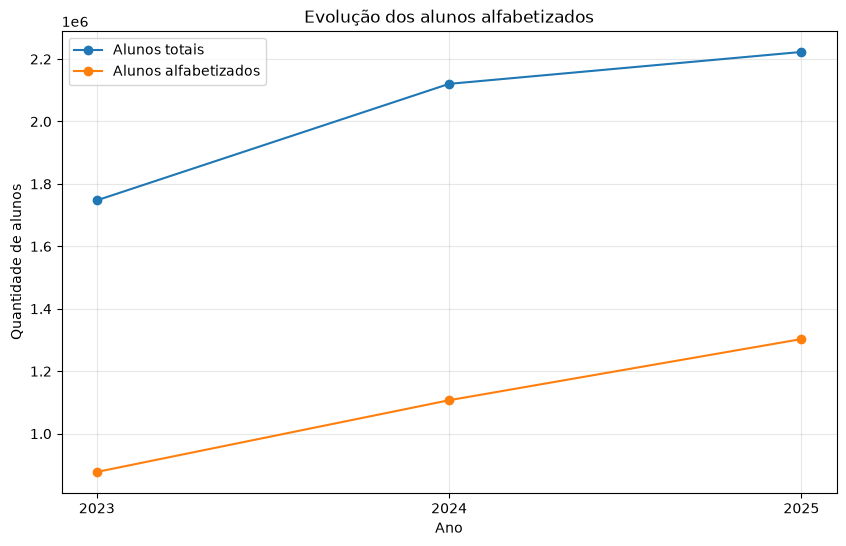

In [356]:
import matplotlib.pyplot as plt

import numpy as np

df_plot = (
    df_alunos
    .groupby("NU_ANO_AVALIACAO")
    .agg(
        ALUNOS_TOTAL=("ID_ALUNO", "nunique"),
        ALUNOS_ALFABETIZADOS=("IN_ALFABETIZADO", lambda x: (x == 1).sum())
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    df_plot["NU_ANO_AVALIACAO"],
    df_plot["ALUNOS_TOTAL"],
    marker="o",
    label="Alunos totais"
)

plt.plot(
    df_plot["NU_ANO_AVALIACAO"],
    df_plot["ALUNOS_ALFABETIZADOS"],
    marker="o",
    label="Alunos alfabetizados"
)

plt.title("Evolução dos alunos alfabetizados")
plt.xlabel("Ano")
plt.ylabel("Quantidade de alunos")
plt.xticks(df_plot["NU_ANO_AVALIACAO"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

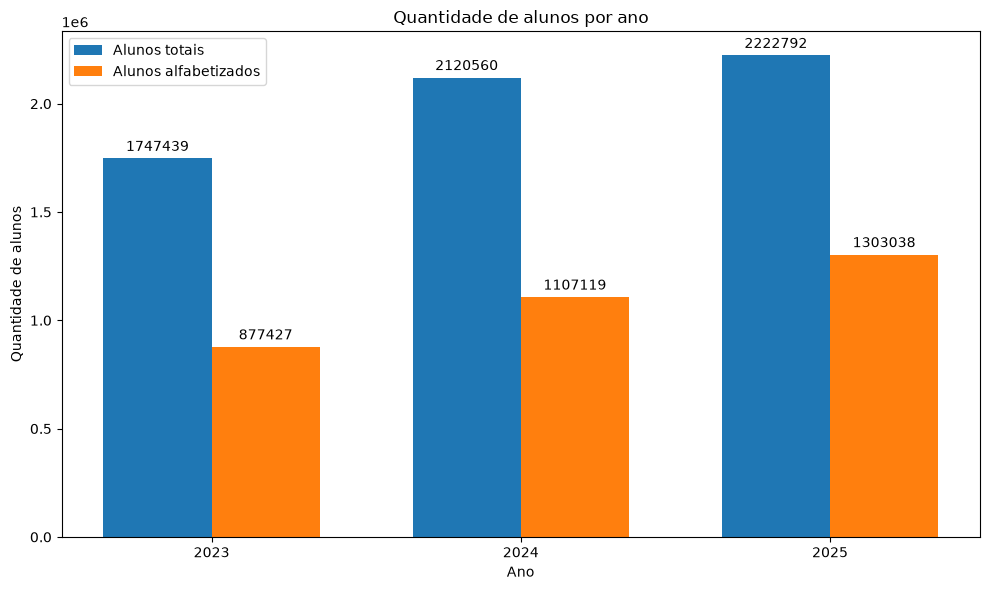

In [353]:


fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_plot["NU_ANO_AVALIACAO"]))
largura = 0.35

barras_total = ax.bar(
    x - largura/2,
    df_plot["ALUNOS_TOTAL"],
    width=largura,
    label="Alunos totais"
)

barras_alf = ax.bar(
    x + largura/2,
    df_plot["ALUNOS_ALFABETIZADOS"],
    width=largura,
    label="Alunos alfabetizados"
)

ax.set_title("Quantidade de alunos por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade de alunos")
ax.set_xticks(x)
ax.set_xticklabels(df_plot["NU_ANO_AVALIACAO"])
ax.legend()

# Valores sobre as barras
ax.bar_label(barras_total, fmt="%.0f", padding=3)
ax.bar_label(barras_alf, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

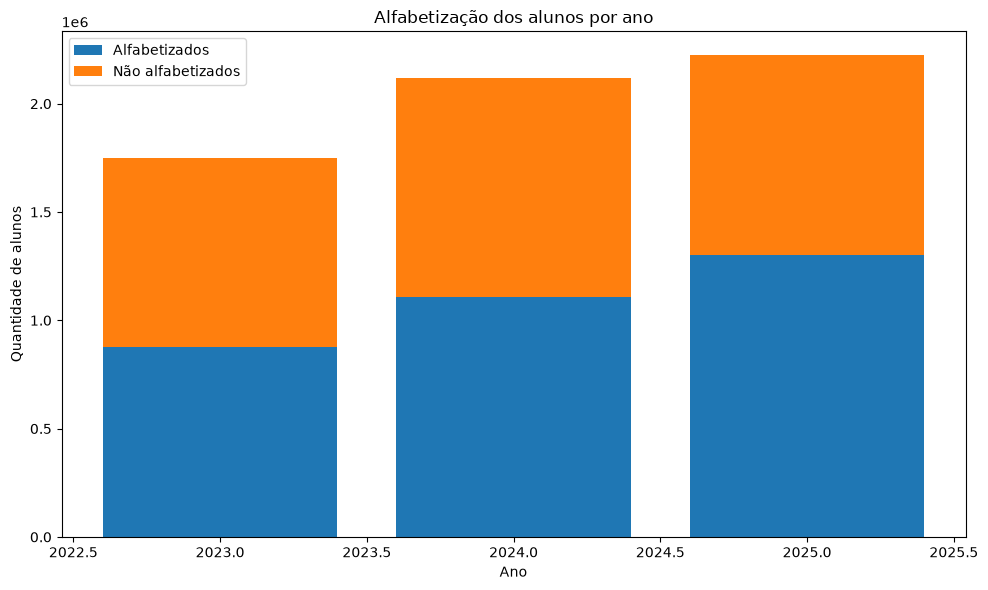

In [348]:
df_plot["ALUNOS_NAO_ALFABETIZADOS"] = (
    df_plot["ALUNOS_TOTAL"] -
    df_plot["ALUNOS_ALFABETIZADOS"]
)

plt.figure(figsize=(10, 6))

plt.bar(
    df_plot["NU_ANO_AVALIACAO"],
    df_plot["ALUNOS_ALFABETIZADOS"],
    label="Alfabetizados"
)

plt.bar(
    df_plot["NU_ANO_AVALIACAO"],
    df_plot["ALUNOS_NAO_ALFABETIZADOS"],
    bottom=df_plot["ALUNOS_ALFABETIZADOS"],
    label="Não alfabetizados"
)

plt.title("Alfabetização dos alunos por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de alunos")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
df_municipio = (
    df_alunos
    .groupby(["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO"])
    .agg(
        TOTAL=("ID_ALUNO", "nunique"),
        ALFABETIZADOS=("IN_ALFABETIZADO", lambda x: (x == 1).sum())
    )
    .reset_index()
)

df_municipio["TAXA_ALFABETIZACAO"] = (
    df_municipio["ALFABETIZADOS"] /
    df_municipio["TOTAL"] * 100
)

,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,TOTAL,ALFABETIZADOS,TAXA_ALFABETIZACAO
0,2023,11,1100015.0,254,153,60.236220
1,2023,11,1100023.0,1361,764,56.135195
2,2023,11,1100031.0,84,54,64.285714
3,2023,11,1100049.0,953,517,54.249738
4,2023,11,1100056.0,241,127,52.697095
5,2023,11,1100064.0,169,93,55.029586
6,2023,11,1100072.0,129,71,55.038760
7,2023,11,1100080.0,235,171,72.765957
8,2023,11,1100098.0,470,356,75.744681
9,2023,11,1100106.0,542,234,43.173432


In [373]:
display(df_municipio.sort_values(["CO_MUNICIPIO","NU_ANO_AVALIACAO", "TAXA_ALFABETIZACAO"], ascending=[True, True, False]))

,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,TOTAL,ALFABETIZADOS,TAXA_ALFABETIZACAO
0,2023,11,1100015.0,254,153,60.236220
4873,2024,11,1100015.0,306,187,61.111111
10392,2025,11,1100015.0,295,211,71.525424
1,2023,11,1100023.0,1361,764,56.135195
4874,2024,11,1100023.0,1201,702,58.451291
...,...,...,...,...,...,...
4872,2023,52,5222302.0,72,48,66.666667
10390,2024,52,5222302.0,73,52,71.232877
15946,2025,52,5222302.0,79,62,78.481013
10391,2024,53,5300108.0,27698,13140,47.440248


In [374]:
df_uf = (
    df_alunos
    .groupby(["NU_ANO_AVALIACAO", "CO_UF"])
    .agg(
        TOTAL=("ID_ALUNO", "nunique"),
        ALFABETIZADOS=("IN_ALFABETIZADO", lambda x: (x == 1).sum())
    )
    .reset_index()
)

df_uf["TAXA_ALFABETIZACAO"] = (
    df_uf["ALFABETIZADOS"] /
    df_uf["TOTAL"] * 100
)

In [377]:
display(df_uf.sort_values(["CO_UF", "NU_ANO_AVALIACAO", "TAXA_ALFABETIZACAO"], ascending=[True, True, False]))

,NU_ANO_AVALIACAO,CO_UF,TOTAL,ALFABETIZADOS,TAXA_ALFABETIZACAO
0,2023,11,22834,13126,57.484453
23,2024,11,22673,12621,55.665329
49,2025,11,26639,16070,60.325087
24,2024,12,12655,5311,41.967602
50,2025,12,12741,7158,56.180834
...,...,...,...,...,...
22,2023,52,83741,48821,58.299996
47,2024,52,77166,51698,66.995827
74,2025,52,81175,57607,70.966431
48,2024,53,27698,13140,47.440248


In [ ]:
#cruzar rendimento com taxa de alfabetização



NameError: name 'df_analise' is not defined

Target: Alunos alfabetizados

Quantidade de alunos alfabetizados

In [ ]:
df_alunos["IN_ALFABETIZADO"].value_counts(dropna=False)

IN_ALFABETIZADO
1    3287584
0    2803207
Name: count, dtype: Int64

Proporção de alunos alfabetizados vs não alfabetizados

In [ ]:
df_alunos["IN_ALFABETIZADO"].value_counts(normalize=True, dropna=False)

IN_ALFABETIZADO
1    0.539763
0    0.460237
Name: proportion, dtype: Float64

Quantidade de avaliaçoes por ano

In [ ]:
if "NU_ANO_AVALIACAO" not in df_alunos.columns and "ANO" in df_alunos.columns:
    df_alunos = df_alunos.rename(columns={"ANO": "NU_ANO_AVALIACAO"})

df_alunos["NU_ANO_AVALIACAO"].value_counts().sort_index()

NU_ANO_AVALIACAO
2023    1747439
2024    2120560
2025    2222792
Name: count, dtype: Int64

Evolução temporal
Proporção de alunos Alfabetizados por ano

In [ ]:
pd.crosstab(
    df_alunos["NU_ANO_AVALIACAO"],
    df_alunos["IN_ALFABETIZADO"],
    normalize="index"
) * 100

IN_ALFABETIZADO,0,1
NU_ANO_AVALIACAO,,
2023,49.787832,50.212168
2024,47.791197,52.208803
2025,41.378321,58.621679


Podemos notar que estamos evoluindo positivamente a quantidade de alunos alfabetizados ao longo do tempo. +8p.p. em 2 anos.


Primeira hipótese analítica:

H1 — A proporção de alunos alfabetizados apresenta evolução positiva ao longo do período analisado.

Essa evolução aconteceu de forma homogênea ou foi concentrada em determinados territórios?


In [ ]:
df_alunos.groupby("IN_ALFABETIZADO")["VL_PROFICIENCIA_LP"].describe()

,count,mean,std,min,25%,50%,75%,max
IN_ALFABETIZADO,,,,,,,,
0,2033682.0,701.931944,32.675350,572.355874,681.494367,709.411471,729.250713,742.999958
1,3287584.0,780.219544,26.392243,743.000000,759.870886,775.481946,795.056066,904.382031


Aluno
 ├── características educacionais
 ├── escola
 ├── município
 ├── estado
 └── contexto socioeconômico
              ↓
          ML
              ↓
 P(alfabetizado)

Resultado histórico
       +
Previsão dos alunos
       +
Meta
       ↓
Projeção 2030
       ↓
🟢 provável atingir
🟡 atenção
🔴 provável não atingir

VL_PROFICIENCIA_LP < 743
             ↓
   IN_ALFABETIZADO = 0

VL_PROFICIENCIA_LP >= 743
             ↓
   IN_ALFABETIZADO = 1

as métricas calculadas como 
PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO
VL_MEDIA_LP_TOTAL_MUNICIPIO
PC_ALUNO_ALFABETIZADO_TOTAL_UF
VL_MEDIA_LP_TOTAL_UF 
não entram no modelo, porque seriam Data Leakeage, já que foram calculadas a partir dos resultados das avaliaçoes



In [ ]:
df_alunos.groupby("SG_UF").agg(
    alunos=("ID_ALUNO", "count"),
    alfabetizados=("IN_ALFABETIZADO", "sum"),
    taxa_alfabetizacao=("IN_ALFABETIZADO", "mean")
).sort_values(
    "taxa_alfabetizacao",
    ascending=False
)

KeyError: 'SG_UF'

In [ ]:
df_alunos.groupby(
    ["NU_ANO_AVALIACAO", "SG_UF"]
).agg(
    alunos=("ID_ALUNO", "count"),
    taxa_alfabetizacao=("IN_ALFABETIZADO", "mean")
).reset_index()

KeyError: 'SG_UF'

In [37]:
df_uf_ano = (
    df_alunos
    .groupby(["NU_ANO_AVALIACAO", "SG_UF"])
    .agg(
        alunos=("ID_ALUNO", "count"),
        taxa_alfabetizacao=("IN_ALFABETIZADO", "mean")
    )
    .reset_index()
)

# transformar de proporção para percentual
df_uf_ano["taxa_alfabetizacao"] *= 100

df_uf_ano.head()

,NU_ANO_AVALIACAO,SG_UF,alunos,taxa_alfabetizacao
0,2023,AL,35503,41.078219
1,2023,AM,63055,40.57093
2,2023,AP,12349,37.32286
3,2023,BA,137724,31.574744
4,2023,CE,100349,80.660495


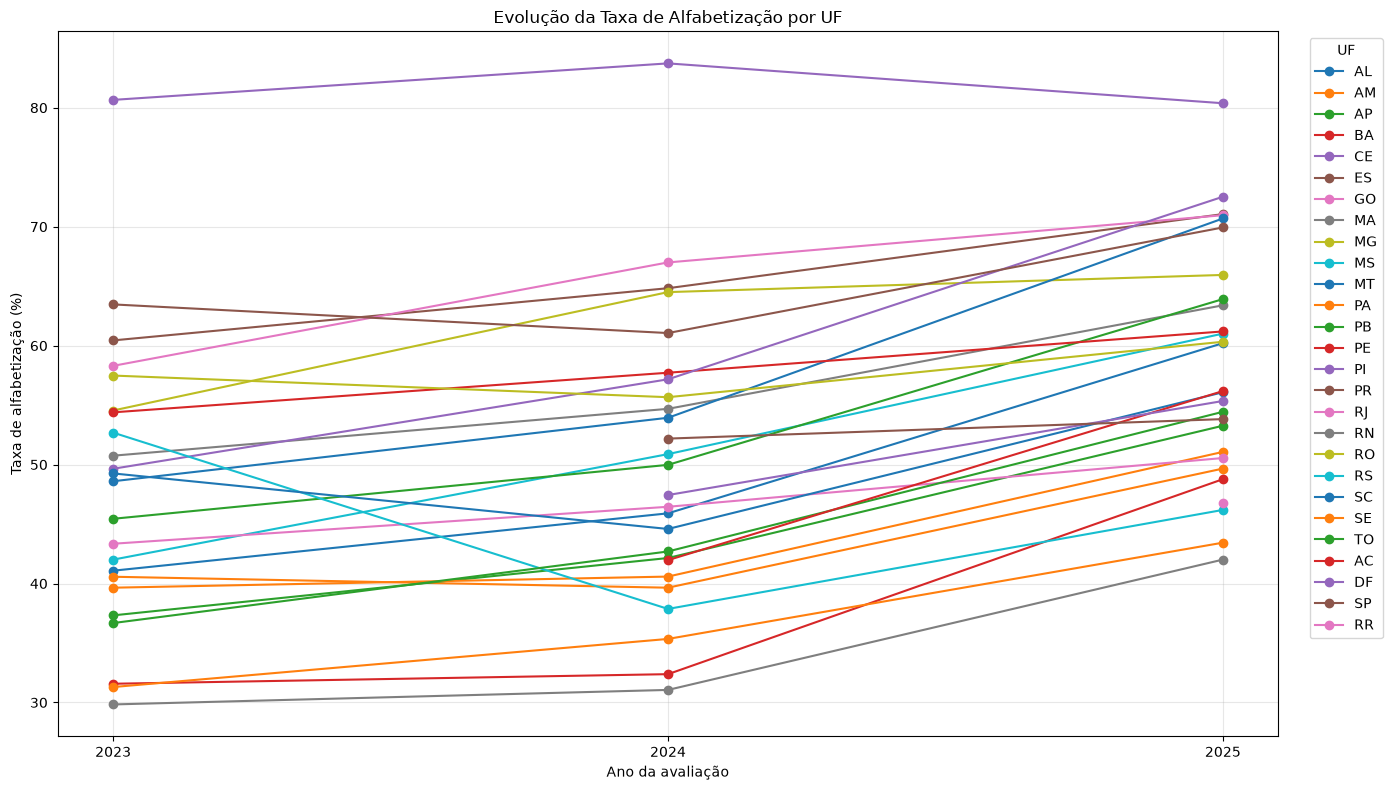

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

for uf in df_uf_ano["SG_UF"].unique():
    dados_uf = df_uf_ano[df_uf_ano["SG_UF"] == uf]
    
    plt.plot(
        dados_uf["NU_ANO_AVALIACAO"],
        dados_uf["taxa_alfabetizacao"],
        marker="o",
        label=uf
    )

plt.title("Evolução da Taxa de Alfabetização por UF")
plt.xlabel("Ano da avaliação")
plt.ylabel("Taxa de alfabetização (%)")
plt.xticks(sorted(df_uf_ano["NU_ANO_AVALIACAO"].unique()))
plt.legend(
    title="UF",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

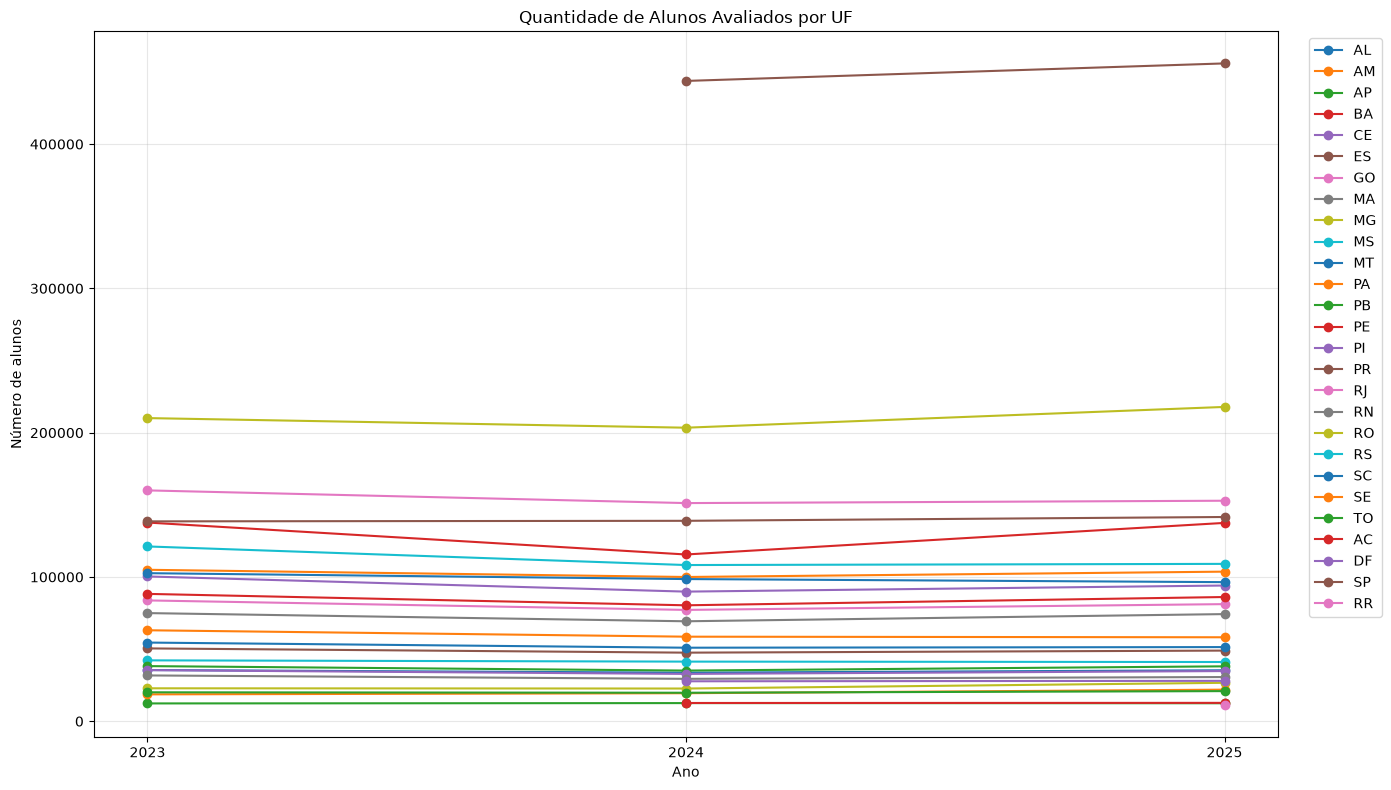

In [39]:
plt.figure(figsize=(14, 8))

for uf in df_uf_ano["SG_UF"].unique():
    dados = df_uf_ano[df_uf_ano["SG_UF"] == uf]
    
    plt.plot(
        dados["NU_ANO_AVALIACAO"],
        dados["alunos"],
        marker="o",
        label=uf
    )

plt.title("Quantidade de Alunos Avaliados por UF")
plt.xlabel("Ano")
plt.ylabel("Número de alunos")
plt.xticks([2023, 2024, 2025])
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
df_heatmap = df_uf_ano.pivot(
    index="SG_UF",
    columns="NU_ANO_AVALIACAO",
    values="taxa_alfabetizacao"
)

df_heatmap

NU_ANO_AVALIACAO,2023,2024,2025
SG_UF,,,
AC,<NA>,41.967602,56.180834
AL,41.078219,45.901152,60.207172
AM,40.57093,39.649877,49.663207
AP,37.32286,42.146264,53.266453
BA,31.574744,32.380425,48.770978
CE,80.660495,83.729032,80.37867
DF,<NA>,47.440248,55.346047
ES,60.439365,64.828137,71.05892
GO,58.299996,66.995827,70.966431


## <font color="blue">Novos fatos</font>

In [216]:
bases = {
    "df_fact_escola": df_fact_escola,
    "df_fact_municipio": df_fact_municipio,
    "df_fact_uf_ano": df_fact_uf_ano,
    "df_dim_contexto_socioeconomico_uf": df_dim_contexto_socioeconomico_uf,
    "df_fato_alfabetizacao": df_alfabetizacao,
    "df_fato_alfabetizacao_meta": df_meta,
    "df_ranking_prioridade": df_ranking_prioridade,
    "df_analise_uf": df_analise_uf,
    "df_analise_municipio": df_analise_municipio
}

### Verificaçoes 

In [ ]:
for nome, df in bases.items():
    print("=" * 80)
    print(nome)
    print("Dimensão:", df.shape)
    print("Colunas:", df.columns.tolist())
    print()

df_fact_escola
Dimensão: (517080, 15)
Colunas: ['ANO', 'COD_UF', 'CO_MUNICIPIO', 'CO_ENTIDADE', 'FUN_02_CAT_0', 'COD_RISCO_ESCOLA', 'CATEGORIA_RISCO_ESCOLA', 'NIVEL_RISCO_DESC_ESCOLA', 'DESC_IMPACTO_ESCOLA', 'QT_MATRICULA_2ANO_EF', 'UF_POPULACAO_MIL', 'UF_TAXA_ANALFABETISMO_PCT', 'UF_RENDIMENTO_MEDIO_MENSAL_REAIS', 'UF_RENDA_PERCAPITA_SBENEF_MEDIO', 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT']

df_fact_municipio
Dimensão: (16711, 14)
Colunas: ['ANO', 'COD_UF', 'CO_MUNICIPIO', 'FUN_02_CAT_0', 'COD_RISCO_UF', 'CATEGORIA_RISCO_UF', 'COD_RISCO_MUNICIPIO', 'CATEGORIA_RISCO_MUNICIPIO', 'NIVEL_RISCO_DESC_MUNICIPIO', 'UF_POPULACAO_MIL', 'UF_TAXA_ANALFABETISMO_PCT', 'UF_RENDIMENTO_MEDIO_MENSAL_REAIS', 'UF_RENDA_PERCAPITA_SBENEF_MEDIO', 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT']

df_fact_uf_ano
Dimensão: (81, 32)
Colunas: ['ANO', 'COD_REGIAO', 'NO_REGIAO', 'COD_UF', 'SG_UF', 'UNIDGEO', 'ED_INF_CAT_0', 'CRE_CAT_0', 'PRE_CAT_0', 'FUN_CAT_0', 'FUN_AI_CAT_0', 'FUN_AF_CAT_0', 'FUN_01_CAT_0', 'FUN_02_CAT_0', 'FUN_03_CAT_0'

In [218]:
for nome, df in bases.items():
    print("=" * 80)
    print(nome)
    print(df.dtypes)
    print()

df_fact_escola
ANO                                 float64
COD_UF                                int64
CO_MUNICIPIO                        float64
CO_ENTIDADE                         float64
FUN_02_CAT_0                        float64
COD_RISCO_ESCOLA                    float64
CATEGORIA_RISCO_ESCOLA                  str
NIVEL_RISCO_DESC_ESCOLA                 str
DESC_IMPACTO_ESCOLA                     str
QT_MATRICULA_2ANO_EF                float64
UF_POPULACAO_MIL                      int64
UF_TAXA_ANALFABETISMO_PCT           float64
UF_RENDIMENTO_MEDIO_MENSAL_REAIS      int64
UF_RENDA_PERCAPITA_SBENEF_MEDIO     float64
UF_TAXA_FREQ_LIQUIDA_FUND_PCT       float64
dtype: object

df_fact_municipio
ANO                                 float64
COD_UF                                int64
CO_MUNICIPIO                        float64
FUN_02_CAT_0                        float64
COD_RISCO_UF                        float64
CATEGORIA_RISCO_UF                      str
COD_RISCO_MUNICIPIO         

In [219]:
for nome, df in bases.items():
    print("=" * 80)
    print(nome)
    print("\nNulos:")
    display(
        df.isna()
        .sum()
        .sort_values(ascending=False)
    )

print("\nDuplicados:")
print(df.duplicated().sum())

df_fact_escola

Nulos:


QT_MATRICULA_2ANO_EF                387289
COD_RISCO_ESCOLA                    387277
CATEGORIA_RISCO_ESCOLA              387277
NIVEL_RISCO_DESC_ESCOLA             387277
DESC_IMPACTO_ESCOLA                 387277
FUN_02_CAT_0                        235695
ANO                                      0
COD_UF                                   0
CO_MUNICIPIO                             0
CO_ENTIDADE                              0
UF_POPULACAO_MIL                         0
UF_TAXA_ANALFABETISMO_PCT                0
UF_RENDIMENTO_MEDIO_MENSAL_REAIS         0
UF_RENDA_PERCAPITA_SBENEF_MEDIO          0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT            0
dtype: int64

df_fact_municipio

Nulos:


COD_RISCO_MUNICIPIO                 312
CATEGORIA_RISCO_MUNICIPIO           312
NIVEL_RISCO_DESC_MUNICIPIO          312
COD_RISCO_UF                         72
CATEGORIA_RISCO_UF                   72
FUN_02_CAT_0                          2
ANO                                   0
COD_UF                                0
CO_MUNICIPIO                          0
UF_POPULACAO_MIL                      0
UF_TAXA_ANALFABETISMO_PCT             0
UF_RENDIMENTO_MEDIO_MENSAL_REAIS      0
UF_RENDA_PERCAPITA_SBENEF_MEDIO       0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT         0
dtype: int64

df_fact_uf_ano

Nulos:


...

df_analise_uf

Nulos:


GAP_META_UF                         27
META_UF_REFERENCIA                  27
META_UF_FINAL_2024                   6
META_UF_FINAL_2025                   3
META_UF_FINAL_2026                   3
META_UF_FINAL_2027                   3
META_UF_FINAL_2028                   3
META_UF_FINAL_2029                   3
NU_ANO_AVALIACAO                     0
UF_POPULACAO_MIL                     0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT        0
UF_RENDA_PERCAPITA_SBENEF_MEDIO      0
UF_RENDIMENTO_MEDIO_MENSAL_REAIS     0
UF_TAXA_ANALFABETISMO_PCT            0
META_UF_FINAL_2030                   0
CATEGORIA_RISCO_UF                   0
COD_RISCO_UF                         0
CO_UF                                0
ALFABETIZACAO_UF                     0
MEDIA_LP_UF                          0
TP_SERIE                             0
ATINGIU_META_UF                      0
dtype: int64

df_analise_municipio

Nulos:


DIF_META_MUNICIPIO                  5370
META_MUNICIPIO_REFERENCIA           5370
META_MUNICIPIO_FINAL_2024            558
META_MUNICIPIO_FINAL_2025            438
META_MUNICIPIO_FINAL_2028            392
META_MUNICIPIO_FINAL_2026            392
META_MUNICIPIO_FINAL_2027            392
META_MUNICIPIO_FINAL_2029            392
META_MUNICIPIO_FINAL_2030            392
NIVEL_RISCO_DESC_MUNICIPIO           263
CATEGORIA_RISCO_MUNICIPIO            263
COD_RISCO_MUNICIPIO                  263
CATEGORIA_RISCO_UF                    43
COD_RISCO_UF                          43
FUN_02_CAT_0                           2
UF_RENDA_PERCAPITA_SBENEF_MEDIO        0
UF_TAXA_ANALFABETISMO_PCT              0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT          0
ATINGIU_META_MUNICIPIO                 0
UF_RENDIMENTO_MEDIO_MENSAL_REAIS       0
NU_ANO_AVALIACAO                       0
UF_POPULACAO_MIL                       0
CO_UF                                  0
ALFABETIZACAO_MUNICIPIO                0
MEDIA_LP_MUNICIP


Duplicados:
0


### 1. Tratativa de duplicidades - erro de cidade=estado

#### df_fact_uf_ano
tratativa duplicidade estado e municipio rj e sp 

In [97]:
sorted(df_fact_uf_ano["ANO"].unique())

[np.int64(2023), np.int64(2024), np.int64(2025)]

In [118]:
df_fact_uf_ano.groupby("ANO").size()

ANO
2023    27
2024    27
2025    27
dtype: int64

In [119]:
for ano in sorted(df_fact_uf_ano["ANO"].unique()):
    
    print(f"\n{'='*50}")
    print(f"ANO: {ano}")
    
    display(
        df_fact_uf_ano[
            df_fact_uf_ano["ANO"] == ano
        ][["ANO", "COD_UF", "SG_UF", "NO_REGIAO", "UNIDGEO"]]
        .sort_values("COD_UF")
    )


ANO: 2023


,ANO,COD_UF,SG_UF,NO_REGIAO,UNIDGEO
0,2023,11.0,RO,Norte,Rondônia
1,2023,12.0,AC,Norte,Acre
2,2023,13.0,AM,Norte,Amazonas
3,2023,14.0,RR,Norte,Roraima
4,2023,15.0,PA,Norte,Pará
5,2023,16.0,AP,Norte,Amapá
6,2023,17.0,TO,Norte,Tocantins
7,2023,21.0,MA,Nordeste,Maranhão
8,2023,22.0,PI,Nordeste,Piauí
9,2023,23.0,CE,Nordeste,Ceará



ANO: 2024


,ANO,COD_UF,SG_UF,NO_REGIAO,UNIDGEO
27,2024,11.0,RO,Norte,Rondônia
28,2024,12.0,AC,Norte,Acre
29,2024,13.0,AM,Norte,Amazonas
30,2024,14.0,RR,Norte,Roraima
31,2024,15.0,PA,Norte,Pará
32,2024,16.0,AP,Norte,Amapá
33,2024,17.0,TO,Norte,Tocantins
34,2024,21.0,MA,Nordeste,Maranhão
35,2024,22.0,PI,Nordeste,Piauí
36,2024,23.0,CE,Nordeste,Ceará



ANO: 2025


,ANO,COD_UF,SG_UF,NO_REGIAO,UNIDGEO
54,2025,11.0,RO,Norte,Rondônia
55,2025,12.0,AC,Norte,Acre
56,2025,13.0,AM,Norte,Amazonas
57,2025,14.0,RR,Norte,Roraima
58,2025,15.0,PA,Norte,Pará
59,2025,16.0,AP,Norte,Amapá
60,2025,17.0,TO,Norte,Tocantins
61,2025,21.0,MA,Nordeste,Maranhão
62,2025,22.0,PI,Nordeste,Piauí
63,2025,23.0,CE,Nordeste,Ceará


In [120]:
df_fact_uf_ano[
    (df_fact_uf_ano["ANO"] == 2023) &
    (df_fact_uf_ano["COD_UF"] == 33)
].T

,18
ANO,2023
COD_REGIAO,3.0
NO_REGIAO,Sudeste
COD_UF,33.0
SG_UF,RJ
UNIDGEO,Rio de Janeiro
ED_INF_CAT_0,5.7
CRE_CAT_0,6.9
PRE_CAT_0,4.9
FUN_CAT_0,5.0


In [116]:
df_fact_uf_ano[
    (df_fact_uf_ano["ANO"] == 2023) &
    (df_fact_uf_ano["COD_UF"] == 35)
].T

,19
ANO,2023
COD_REGIAO,3.0
NO_REGIAO,Sudeste
COD_UF,35.0
SG_UF,SP
UNIDGEO,São Paulo
ED_INF_CAT_0,7.3
CRE_CAT_0,8.9
PRE_CAT_0,5.6
FUN_CAT_0,5.6


In [117]:
df_fact_uf_ano[
    df_fact_uf_ano.duplicated(
        subset=["ANO", "COD_UF"],
        keep=False
    )
].sort_values(["ANO", "COD_UF"])

,ANO,COD_REGIAO,NO_REGIAO,COD_UF,SG_UF,UNIDGEO,ED_INF_CAT_0,CRE_CAT_0,PRE_CAT_0,FUN_CAT_0,...,MED_01_CAT_0,MED_02_CAT_0,MED_03_CAT_0,MED_04_CAT_0,MED_NS_CAT_0,POPULACAO_MIL,TAXA_ANALFABETISMO_PCT,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,TAXA_FREQ_LIQUIDA_FUND_PCT


#### df_fact_escola
tratativa duplicidade estado e municipio rj e sp 
correçao das duplicidades do val;or da cidade de sp e rj que subiu como estado, duplicando o valor.

In [114]:
condicao = (
    (df_fact_uf_ano["ANO"] == 2023) &
    (df_fact_uf_ano["COD_UF"] == 33) &
    (df_fact_uf_ano["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3477.73676)
)

df_fact_uf_ano = df_fact_uf_ano[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_uf_ano["ANO"] == 2023) &
    (df_fact_uf_ano["COD_UF"] == 35) &
    (df_fact_uf_ano["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3357.80555)
)

df_fact_uf_ano = df_fact_uf_ano[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_uf_ano["ANO"] == 2024) &
    (df_fact_uf_ano["COD_UF"] == 33) &
    (df_fact_uf_ano["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3379.23636)
)

df_fact_uf_ano = df_fact_uf_ano[~condicao].reset_index(drop=True)
condicao = (
    (df_fact_uf_ano["ANO"] == 2024) &
    (df_fact_uf_ano["COD_UF"] == 35) &
    (df_fact_uf_ano["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3455.07587)
)

df_fact_uf_ano = df_fact_uf_ano[~condicao].reset_index(drop=True)

In [153]:
cols_uf = [
    "UF_POPULACAO_MIL",
    "UF_TAXA_ANALFABETISMO_PCT",
    "UF_RENDIMENTO_MEDIO_MENSAL_REAIS",
    "UF_RENDA_PERCAPITA_SBENEF_MEDIO",
    "UF_TAXA_FREQ_LIQUIDA_FUND_PCT"
]

teste = (
    df_fact_escola
    .groupby(["ANO", "COD_UF"])[cols_uf]
    .nunique()
)

teste.max()

UF_POPULACAO_MIL                    1
UF_TAXA_ANALFABETISMO_PCT           1
UF_RENDIMENTO_MEDIO_MENSAL_REAIS    1
UF_RENDA_PERCAPITA_SBENEF_MEDIO     1
UF_TAXA_FREQ_LIQUIDA_FUND_PCT       1
dtype: int64

In [154]:
teste[teste["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 1]

,,UF_POPULACAO_MIL,UF_TAXA_ANALFABETISMO_PCT,UF_RENDIMENTO_MEDIO_MENSAL_REAIS,UF_RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT
ANO,COD_UF,,,,,


In [155]:
teste[teste["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 1]

,,UF_POPULACAO_MIL,UF_TAXA_ANALFABETISMO_PCT,UF_RENDIMENTO_MEDIO_MENSAL_REAIS,UF_RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT
ANO,COD_UF,,,,,


In [156]:
df_fact_escola[
    (df_fact_escola["ANO"] == 2023) &
    (df_fact_escola["COD_UF"] == 35)
].T

,108958,108959,108960,108961,108962,108963,108964,108965,108966,108967,...,137884,137885,137886,137887,137888,137889,137890,137891,137892,137893
ANO,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,...,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0
COD_UF,35,35,35,35,35,35,35,35,35,35,...,35,35,35,35,35,35,35,35,35,35
CO_MUNICIPIO,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,...,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0
CO_ENTIDADE,35030806.0,35031045.0,35031082.0,35031100.0,35031112.0,35063113.0,35065262.0,35079911.0,35079923.0,35092319.0,...,35006278.0,35009732.0,35020382.0,35222318.0,35222392.0,35233596.0,35277241.0,35387859.0,35564709.0,35580788.0
FUN_02_CAT_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.3,5.1,NaN,...,9.0,NaN,NaN,9.0,NaN,NaN,NaN,9.0,NaN,NaN
COD_RISCO_ESCOLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,NaN,...,3.0,NaN,NaN,1.0,NaN,NaN,NaN,2.0,NaN,NaN
CATEGORIA_RISCO_ESCOLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderado,Baixo,NaN,...,Moderado,NaN,NaN,Muito baixo,NaN,NaN,NaN,Baixo,NaN,NaN
NIVEL_RISCO_DESC_ESCOLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3 – Risco moderado de não alcançar a meta,2 – Risco moderado-baixo de não alcançar a meta,NaN,...,3 – Risco moderado de não alcançar a meta,NaN,NaN,1 – Baixo risco de não alcançar a meta,NaN,NaN,NaN,2 – Risco moderado-baixo de não alcançar a meta,NaN,NaN
DESC_IMPACTO_ESCOLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Impacto em um grupo médio de estudantes,Impacto em um grupo reduzido de estudantes,NaN,...,Impacto em um grupo médio de estudantes,NaN,NaN,Poucos estudantes impactados,NaN,NaN,NaN,Impacto em um grupo reduzido de estudantes,NaN,NaN
QT_MATRICULA_2ANO_EF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.0,74.0,NaN,...,20.0,NaN,NaN,63.0,NaN,NaN,NaN,57.0,NaN,NaN


In [149]:
condicao = (
    (df_fact_escola["ANO"] == 2023) &
    (df_fact_escola["COD_UF"] == 33) &
    (df_fact_escola["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3477.73676)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_escola["ANO"] == 2023) &
    (df_fact_escola["COD_UF"] == 35) &
    (df_fact_escola["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3357.80555)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_escola["ANO"] == 2024) &
    (df_fact_escola["COD_UF"] == 33) &
    (df_fact_escola["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3379.23636)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)
condicao = (
    (df_fact_escola["ANO"] == 2024) &
    (df_fact_escola["COD_UF"] == 35) &
    (df_fact_escola["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3455.07587)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

In [ ]:
condicao = (
    (df_fact_escola["ANO"] == 2023) &
    (df_fact_escola["COD_UF"] == 33) &
    (df_fact_escola["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 89.14750)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_escola["ANO"] == 2023) &
    (df_fact_escola["COD_UF"] == 35) &
    (df_fact_escola["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.4743)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_escola["ANO"] == 2024) &
    (df_fact_escola["COD_UF"] == 33) &
    (df_fact_escola["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 91.31985)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_escola["ANO"] == 2024) &
    (df_fact_escola["COD_UF"] == 35) &
    (df_fact_escola["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.0172)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

In [163]:
import io

caminho_s3 = "gold/dados_externos/fact_uf_ano.parquet"

buffer = io.BytesIO()

df_fact_uf_ano.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Arquivo salvo em s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Arquivo salvo em s3://postech-challenge-datascience-003/gold/dados_externos/fact_uf_ano.parquet


#### df_fact_municipio
tratativa duplicidade estado e municipio rj e sp 

In [182]:
condicao = (
    (df_fact_municipio["ANO"] == 2023) &
    (df_fact_municipio["COD_UF"] == 33) &
    (df_fact_municipio["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3477.73676)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_municipio["ANO"] == 2023) &
    (df_fact_municipio["COD_UF"] == 35) &
    (df_fact_municipio["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3357.80555)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_municipio["ANO"] == 2024) &
    (df_fact_municipio["COD_UF"] == 33) &
    (df_fact_municipio["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3379.23636)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)
condicao = (
    (df_fact_municipio["ANO"] == 2024) &
    (df_fact_municipio["COD_UF"] == 35) &
    (df_fact_municipio["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3455.07587)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

In [183]:
condicao = (
    (df_fact_municipio["ANO"] == 2023) &
    (df_fact_municipio["COD_UF"] == 33) &
    (df_fact_municipio["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 89.14750)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_municipio["ANO"] == 2023) &
    (df_fact_municipio["COD_UF"] == 35) &
    (df_fact_municipio["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.4743)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_municipio["ANO"] == 2024) &
    (df_fact_municipio["COD_UF"] == 33) &
    (df_fact_municipio["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 91.31985)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_municipio["ANO"] == 2024) &
    (df_fact_municipio["COD_UF"] == 35) &
    (df_fact_municipio["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.0172)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

In [184]:
chave = ["ANO", "COD_UF", "CO_MUNICIPIO"]

duplicados = (
    df_fact_municipio
    .groupby(chave)
    .size()
    .reset_index(name="qtd_registros")
    .query("qtd_registros > 1")
)

print(f"Combinações duplicadas: {len(duplicados)}")

display(duplicados)

Combinações duplicadas: 0


,ANO,COD_UF,CO_MUNICIPIO,qtd_registros


In [185]:
import io

caminho_s3 = "gold/dados_externos/fact_municipio.parquet"

buffer = io.BytesIO()

df_fact_municipio.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Arquivo salvo em s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Arquivo salvo em s3://postech-challenge-datascience-003/gold/dados_externos/fact_municipio.parquet


#### dim_contexto_socioeconomico_uf
tratativa duplicidade estado e municipio rj e sp 

In [192]:
condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2023) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 33) &
    (df_dim_contexto_socioeconomico_uf["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3477.73676)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2023) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 35) &
    (df_dim_contexto_socioeconomico_uf["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3357.80555)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2024) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 33) &
    (df_dim_contexto_socioeconomico_uf["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3379.23636)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)
condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2024) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 35) &
    (df_dim_contexto_socioeconomico_uf["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3455.07587)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

In [193]:
condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2023) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 33) &
    (df_dim_contexto_socioeconomico_uf["TAXA_FREQ_LIQUIDA_FUND_PCT"] > 89.14750)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2023) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 35) &
    (df_dim_contexto_socioeconomico_uf["TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.4743)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2024) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 33) &
    (df_dim_contexto_socioeconomico_uf["TAXA_FREQ_LIQUIDA_FUND_PCT"] > 91.31985)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2024) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 35) &
    (df_dim_contexto_socioeconomico_uf["TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.0172)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

In [194]:
chave = ["ANO", "COD_UF"]

duplicados = (
    df_dim_contexto_socioeconomico_uf
    .groupby(chave)
    .size()
    .reset_index(name="qtd_registros")
    .query("qtd_registros > 1")
)

print(f"Combinações duplicadas: {len(duplicados)}")

display(duplicados)

Combinações duplicadas: 0


,ANO,COD_UF,qtd_registros


In [195]:

caminho_s3 = "gold/dados_externos/dim_contexto_socioeconomico_uf.parquet"

buffer = io.BytesIO()

df_dim_contexto_socioeconomico_uf.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Arquivo salvo em s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Arquivo salvo em s3://postech-challenge-datascience-003/gold/dados_externos/dim_contexto_socioeconomico_uf.parquet


#### ranking_prioridade
tratativa duplicidade estado e municipio rj e sp 

In [205]:
chave = ["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO"]

duplicados = (
    df_ranking_prioridade
    .groupby(chave)
    .size()
    .reset_index(name="qtd_registros")
    .query("qtd_registros > 1")
)

print(f"Combinações duplicadas: {len(duplicados)}")

display(duplicados)

Combinações duplicadas: 0


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,qtd_registros


In [198]:
condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2023) &
    (df_ranking_prioridade["CO_UF"] == 33) &
    (df_ranking_prioridade["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3477.73676)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2023) &
    (df_ranking_prioridade["CO_UF"] == 35) &
    (df_ranking_prioridade["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3357.80555)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2024) &
    (df_ranking_prioridade["CO_UF"] == 33) &
    (df_ranking_prioridade["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3379.23636)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)
condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2024) &
    (df_ranking_prioridade["CO_UF"] == 35) &
    (df_ranking_prioridade["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3455.07587)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

In [199]:
condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2023) &
    (df_ranking_prioridade["CO_UF"] == 33) &
    (df_ranking_prioridade["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 89.14750)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2023) &
    (df_ranking_prioridade["CO_UF"] == 35) &
    (df_ranking_prioridade["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.4743)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2024) &
    (df_ranking_prioridade["CO_UF"] == 33) &
    (df_ranking_prioridade["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 91.31985)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)
condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2024) &
    (df_ranking_prioridade["CO_UF"] == 35) &
    (df_ranking_prioridade["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.0172)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

In [200]:

caminho_s3 = "gold/dados_externos/ranking_prioridade.parquet"

buffer = io.BytesIO()

df_ranking_prioridade.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Arquivo salvo em s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Arquivo salvo em s3://postech-challenge-datascience-003/gold/dados_externos/ranking_prioridade.parquet


#### analise_uf
tratativa duplicidade estado e municipio rj e sp 

In [215]:
teste_freq = (
    df_analise_uf
    .groupby(["NU_ANO_AVALIACAO", "CO_UF"])["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"]
    .nunique()
    .reset_index(name="qtd_valores")
)

teste_freq[teste_freq["qtd_valores"] > 1]

,NU_ANO_AVALIACAO,CO_UF,qtd_valores


#### analise_municipio
tratativa duplicidade estado e municipio rj e sp 

In [212]:
chave = ["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO"]

duplicados = (
    df_analise_municipio
    .groupby(chave)
    .size()
    .reset_index(name="qtd_registros")
    .query("qtd_registros > 1")
)

print(f"Combinações duplicadas: {len(duplicados)}")

display(duplicados)

Combinações duplicadas: 0


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,qtd_registros


### 2. Nulos

In [224]:
for nome, df in bases.items():

    print("=" * 80)
    print(nome)

    print("\nNulos:")

    nulos = (
        df.isna()
        .sum()
        .sort_values(ascending=False)
        .to_frame("qtd_nulos")
    )

    nulos["pct_nulos"] = (
        nulos["qtd_nulos"] / len(df) * 100
    )

    display(nulos)



df_fact_escola

Nulos:


,qtd_nulos,pct_nulos
QT_MATRICULA_2ANO_EF,387289,74.899242
COD_RISCO_ESCOLA,387277,74.896921
CATEGORIA_RISCO_ESCOLA,387277,74.896921
NIVEL_RISCO_DESC_ESCOLA,387277,74.896921
DESC_IMPACTO_ESCOLA,387277,74.896921
FUN_02_CAT_0,235695,45.581922
ANO,0,0.000000
COD_UF,0,0.000000
CO_MUNICIPIO,0,0.000000
CO_ENTIDADE,0,0.000000


df_fact_municipio

Nulos:


,qtd_nulos,pct_nulos
COD_RISCO_MUNICIPIO,312,1.867034
CATEGORIA_RISCO_MUNICIPIO,312,1.867034
NIVEL_RISCO_DESC_MUNICIPIO,312,1.867034
COD_RISCO_UF,72,0.430854
CATEGORIA_RISCO_UF,72,0.430854
FUN_02_CAT_0,2,0.011968
ANO,0,0.000000
COD_UF,0,0.000000
CO_MUNICIPIO,0,0.000000
UF_POPULACAO_MIL,0,0.000000


df_fact_uf_ano

Nulos:


...

,qtd_nulos,pct_nulos
DIF_META_MUNICIPIO,5370,33.522692
META_MUNICIPIO_REFERENCIA,5370,33.522692
META_MUNICIPIO_FINAL_2024,558,3.483364
META_MUNICIPIO_FINAL_2025,438,2.734253
META_MUNICIPIO_FINAL_2027,392,2.447094
META_MUNICIPIO_FINAL_2028,392,2.447094
META_MUNICIPIO_FINAL_2030,392,2.447094
META_MUNICIPIO_FINAL_2029,392,2.447094
META_MUNICIPIO_FINAL_2026,392,2.447094
CATEGORIA_RISCO_MUNICIPIO,263,1.641800


df_analise_uf

Nulos:


,qtd_nulos,pct_nulos
GAP_META_UF,27,35.526316
META_UF_REFERENCIA,27,35.526316
META_UF_FINAL_2024,6,7.894737
META_UF_FINAL_2025,3,3.947368
META_UF_FINAL_2026,3,3.947368
META_UF_FINAL_2027,3,3.947368
META_UF_FINAL_2028,3,3.947368
META_UF_FINAL_2029,3,3.947368
NU_ANO_AVALIACAO,0,0.000000
UF_POPULACAO_MIL,0,0.000000


df_analise_municipio

Nulos:


,qtd_nulos,pct_nulos
DIF_META_MUNICIPIO,5370,33.522692
META_MUNICIPIO_REFERENCIA,5370,33.522692
META_MUNICIPIO_FINAL_2024,558,3.483364
META_MUNICIPIO_FINAL_2025,438,2.734253
META_MUNICIPIO_FINAL_2028,392,2.447094
META_MUNICIPIO_FINAL_2026,392,2.447094
META_MUNICIPIO_FINAL_2027,392,2.447094
META_MUNICIPIO_FINAL_2029,392,2.447094
META_MUNICIPIO_FINAL_2030,392,2.447094
NIVEL_RISCO_DESC_MUNICIPIO,263,1.641800


In [228]:
#display(df_fact_uf_ano["TAXA_FREQ_LIQUIDA_FUND_PCT"])
df_fact_uf_ano["TAXA_FREQ_LIQUIDA_FUND_PCT"] = df_fact_uf_ano["TAXA_FREQ_LIQUIDA_FUND_PCT"].astype(str)



In [229]:
display(df_fact_uf_ano["TAXA_FREQ_LIQUIDA_FUND_PCT"])

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
     ... 
76    NaN
77    NaN
78    NaN
79    NaN
80    NaN
Name: TAXA_FREQ_LIQUIDA_FUND_PCT, Length: 81, dtype: str